In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ruta_origen = os.path.join("..", "Data", r"C:\Users\avril\itacademy\ProjecteData\Equip_22\Data\INEViajeroOrigenClean11022026.csv")
origen = pd.read_csv(ruta_origen)

In [3]:
ruta_destino = os.path.join("..", "Data",r"C:\Users\avril\itacademy\ProjecteData\Equip_22\Data\INEViajeroDestinoClean11022026.csv" )
destino = pd.read_csv(ruta_destino)

In [4]:
origen

,pais,periodo,viajeros,año,mes,origen
0,Residentes en España,2022M12,3567132,2022,Diciembre,España
1,Residentes en España,2022M11,3541109,2022,Noviembre,España
2,Residentes en España,2022M10,4657750,2022,Octubre,España
3,Residentes en España,2022M09,5178258,2022,Septiembre,España
4,Residentes en España,2022M08,6526507,2022,Agosto,España
...,...,...,...,...,...,...
691,Asia (sin Japón),2021M05,0,2021,Mayo,Resto del Mundo
692,Asia (sin Japón),2021M04,0,2021,Abril,Resto del Mundo
693,Asia (sin Japón),2021M03,0,2021,Marzo,Resto del Mundo
694,Asia (sin Japón),2021M02,0,2021,Febrero,Resto del Mundo


In [5]:
origen.shape #para saber cuantas filas y columnas tiene el dataframe

(696, 6)

In [6]:
origen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696 entries, 0 to 695
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   pais      696 non-null    object
 1   periodo   696 non-null    object
 2   viajeros  696 non-null    int64 
 3   año       696 non-null    int64 
 4   mes       696 non-null    object
 5   origen    696 non-null    object
dtypes: int64(2), object(4)
memory usage: 32.8+ KB


In [7]:
origen.isna().sum().sort_values(ascending=False)


pais        0
periodo     0
viajeros    0
año         0
mes         0
origen      0
dtype: int64

In [8]:
origen['viajeros'] = origen['viajeros'].astype(float)


In [9]:
origen['viajeros'].describe()

count    6.960000e+02
mean     3.351448e+05
std      9.864921e+05
min      0.000000e+00
25%      1.230200e+04
50%      5.125850e+04
75%      1.552532e+05
max      6.935006e+06
Name: viajeros, dtype: float64

In [10]:
origen['origen'].unique()

array(['España', 'El Extranjero', 'Unión Europea', 'Resto de Europa',
       'Resto del Mundo'], dtype=object)

In [11]:
origen['pais_simple'] = origen['origen'].map(lambda x: 'España' if x == 'España' else 'Extranjero')


In [12]:
origen['pais_simple'].unique()

array(['España', 'Extranjero'], dtype=object)

<Axes: title={'center': 'Distribución de viajeros'}, ylabel='Frequency'>

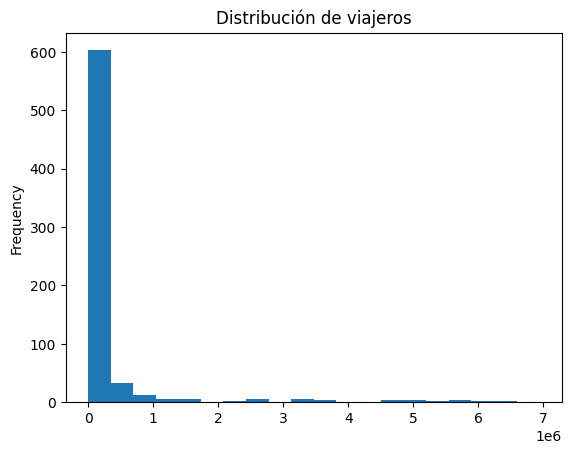

In [13]:
origen['viajeros'].plot(kind='hist', bins=20, title='Distribución de viajeros')

In [14]:
viajeros_por_año=origen.groupby('año')['viajeros'].sum()
viajeros_por_año


año
2021     81082853.0
2022    152177901.0
Name: viajeros, dtype: float64

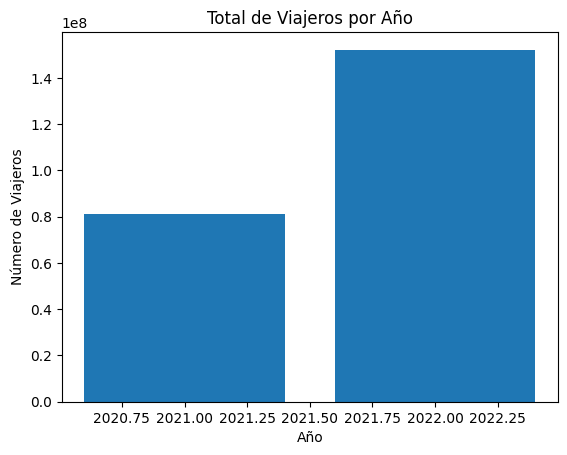

In [15]:
plt.figure()
plt.bar(viajeros_por_año.index, viajeros_por_año.values)
plt.title('Total de Viajeros por Año')
plt.xlabel('Año')
plt.ylabel('Número de Viajeros')
plt.show()


**Crecimiento por año**

In [16]:
crecimiento = ((152177901 - 81082853) / 81082853) * 100
print(f"Crecimiento: {crecimiento:.2f}%")


Crecimiento: 87.68%


In [17]:
origen['mes'].unique()

array(['Diciembre', 'Noviembre', 'Octubre', 'Septiembre', 'Agosto',
       'Julio', 'Junio', 'Mayo', 'Abril', 'Marzo', 'Febrero', 'Enero'],
      dtype=object)

In [18]:
origen['mes'] = origen['mes'].str.strip().str.capitalize()


In [19]:
orden_meses = ['Enero','Febrero','Marzo','Abril','Mayo','Junio',
               'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']
origen['mes'] = pd.Categorical(origen['mes'], categories=orden_meses, ordered=True)

In [20]:
origen['mes'].unique()


['Diciembre', 'Noviembre', 'Octubre', 'Septiembre', 'Agosto', ..., 'Mayo', 'Abril', 'Marzo', 'Febrero', 'Enero']
Length: 12
Categories (12, object): ['Enero' < 'Febrero' < 'Marzo' < 'Abril' ... 'Septiembre' < 'Octubre' < 'Noviembre' < 'Diciembre']

In [21]:
origen['mes'].isna().sum()


np.int64(0)

In [22]:
viajeros_por_mes = origen.groupby('mes', observed=True)['viajeros'].sum()
viajeros_por_mes

mes
Enero          6544196.0
Febrero        8471072.0
Marzo         10754857.0
Abril         14971183.0
Mayo          19373882.0
Junio         23698856.0
Julio         29789296.0
Agosto        33091164.0
Septiembre    28445205.0
Octubre       26466435.0
Noviembre     16563673.0
Diciembre     15090935.0
Name: viajeros, dtype: float64

<Axes: title={'center': 'Viajeros por mes (2021-2022)'}, xlabel='mes'>

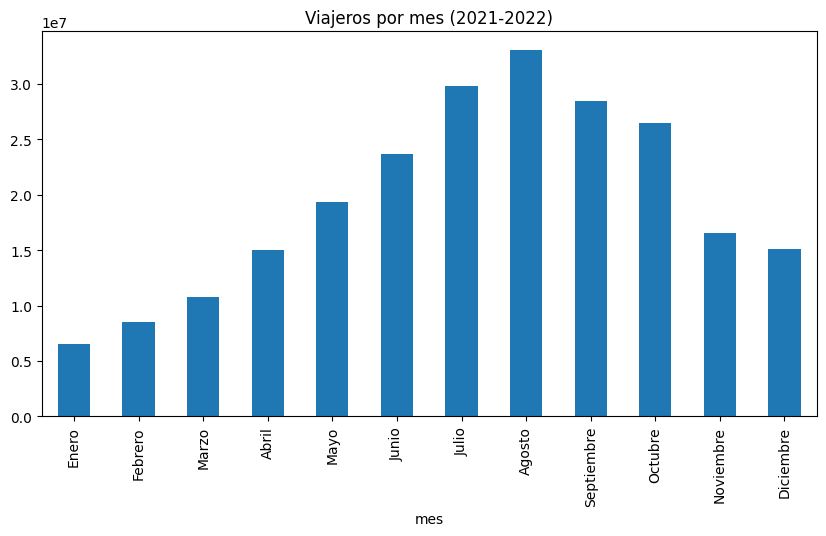

In [135]:
# Total de viajeros por mes 
viajeros_por_mes = origen.groupby('mes', observed=True)['viajeros'].sum()
viajeros_por_mes.plot(kind='bar',
                      title='Viajeros por mes (2021-2022)',
                      figsize=(10,5))

*viajeros por origen*

<Axes: title={'center': 'Viajeros por año y origen'}, xlabel='año'>

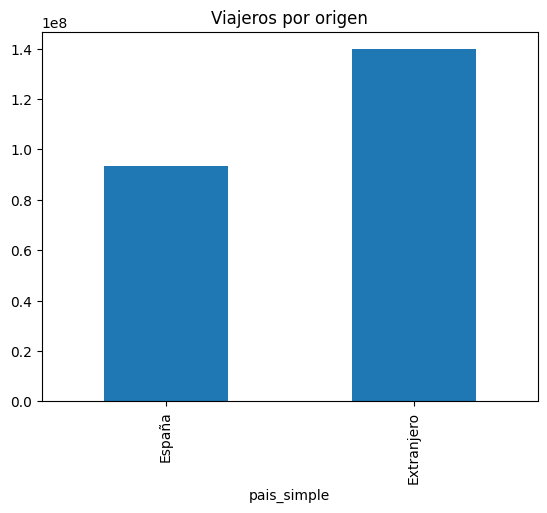

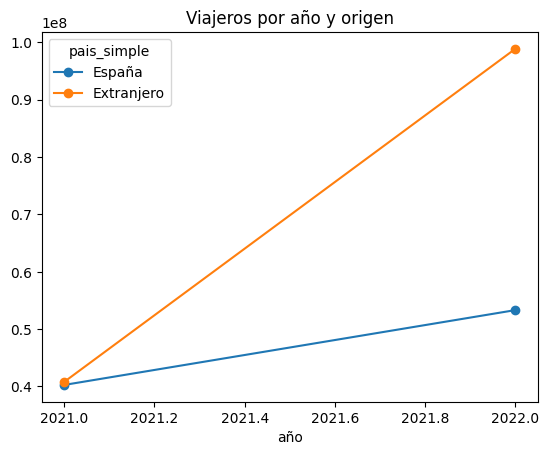

In [133]:
origen.groupby('pais_simple')['viajeros'].sum().plot(kind='bar', title='Viajeros por origen')

# Evolución temporal por origen
viajeros_año_origen = origen.groupby(['año', 'pais_simple'])['viajeros'].sum().unstack()
viajeros_año_origen.plot(kind='line', marker='o', title='Viajeros por año y origen')


pais
Reino Unido                  12071834.0
Alemania                      9677074.0
Francia                       9449826.0
América (sin EEUU)            4886204.0
Estados Unidos de América     3949630.0
Italia                        3932418.0
Países Bajos                  3525122.0
Resto del Mundo               2968119.0
Portugal                      2594336.0
Bélgica                       2167525.0
Name: viajeros, dtype: float64


<Axes: title={'center': 'Top países por año (excluyendo residentes)'}, xlabel='año'>

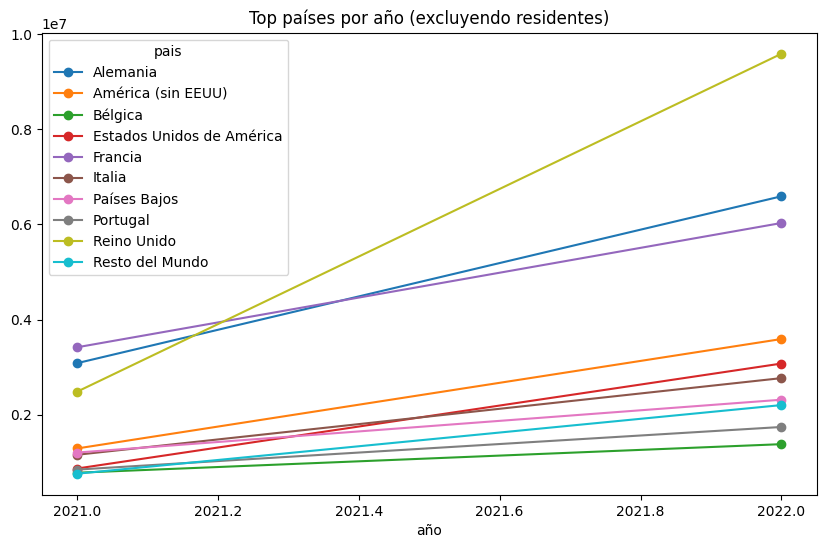

In [ ]:
excluir = ['Residentes en España', 'Residentes en el Extranjero']
origen_filtrado = origen[~origen['pais'].isin(excluir)]

#Calcular el top 10 de países (sin residentes)
top_paises = (origen_filtrado.groupby('pais')['viajeros'].sum().sort_values(ascending=False).head(10))
print(top_paises)

top_paises_index = top_paises.index
df_top = origen_filtrado[origen_filtrado['pais'].isin(top_paises_index)]

# agrupación año y pais
viajeros_pais_año = (
    df_top
    .groupby(['año', 'pais'])['viajeros']
    .sum()
    .unstack()
)

viajeros_pais_año.plot(
    kind='line',
    marker='o',
    figsize=(10,6),
    title='Top países por año (excluyendo residentes)'
)


In [26]:
top_paises

pais
Reino Unido                  12071834.0
Alemania                      9677074.0
Francia                       9449826.0
América (sin EEUU)            4886204.0
Estados Unidos de América     3949630.0
Italia                        3932418.0
Países Bajos                  3525122.0
Resto del Mundo               2968119.0
Portugal                      2594336.0
Bélgica                       2167525.0
Name: viajeros, dtype: float64

C:\Users\avril\AppData\Local\Temp\ipykernel_10004\2023264502.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  origen.groupby(['mes', 'pais_simple'])['viajeros'].sum().unstack().plot(kind='bar', figsize=(10,6), title='Viajeros por mes y origen')


<Axes: title={'center': 'Viajeros por país y origen'}, xlabel='pais'>

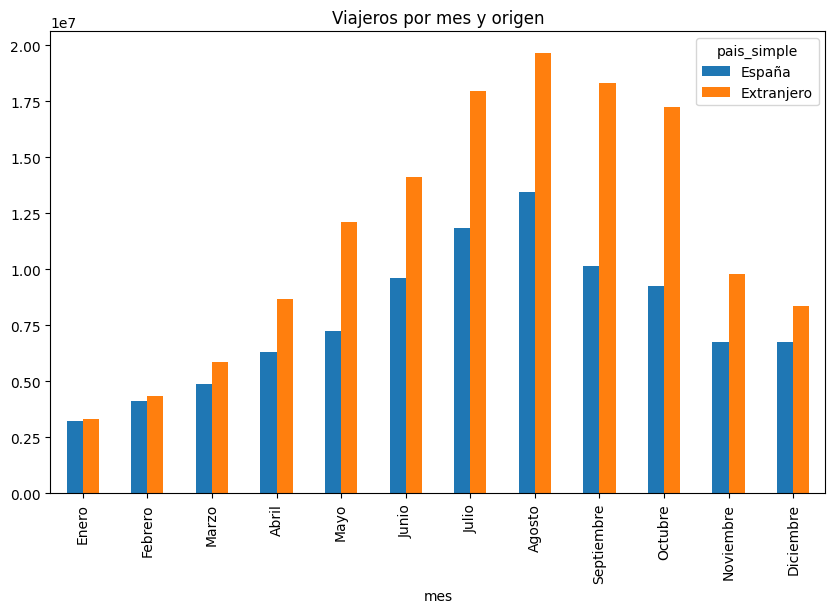

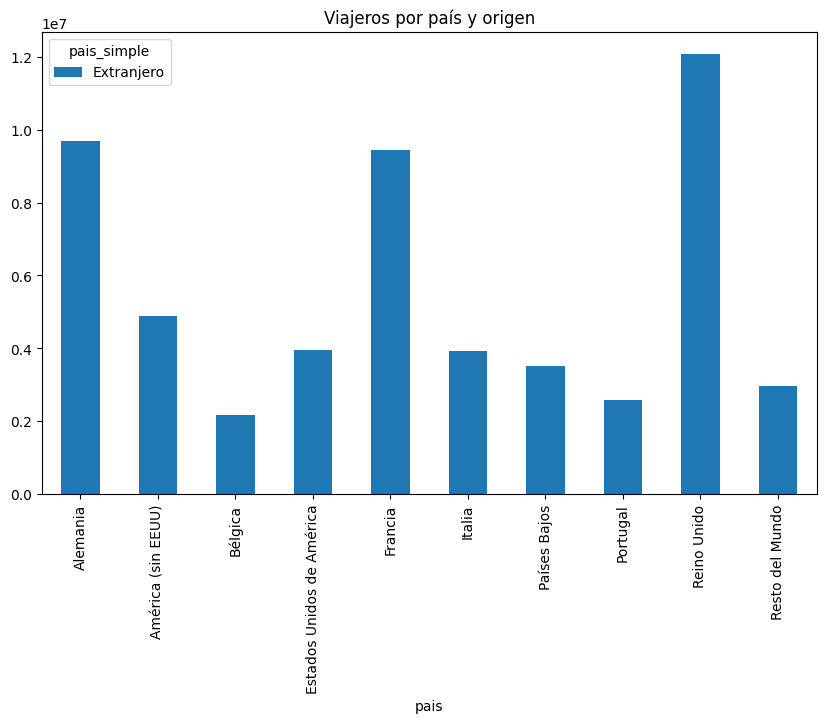

In [27]:
# Origen y mes
origen.groupby(['mes', 'pais_simple'])['viajeros'].sum().unstack().plot(kind='bar', figsize=(10,6), title='Viajeros por mes y origen')

# País y origen (solo top países)
df_top.groupby(['pais', 'pais_simple'])['viajeros'].sum().unstack().plot(kind='bar', figsize=(10,6), title='Viajeros por país y origen')


C:\Users\avril\AppData\Local\Temp\ipykernel_10004\2718176137.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  origen.groupby(['mes', 'año'])['viajeros'].sum().unstack().plot(figsize=(10,6))


<Axes: xlabel='mes'>

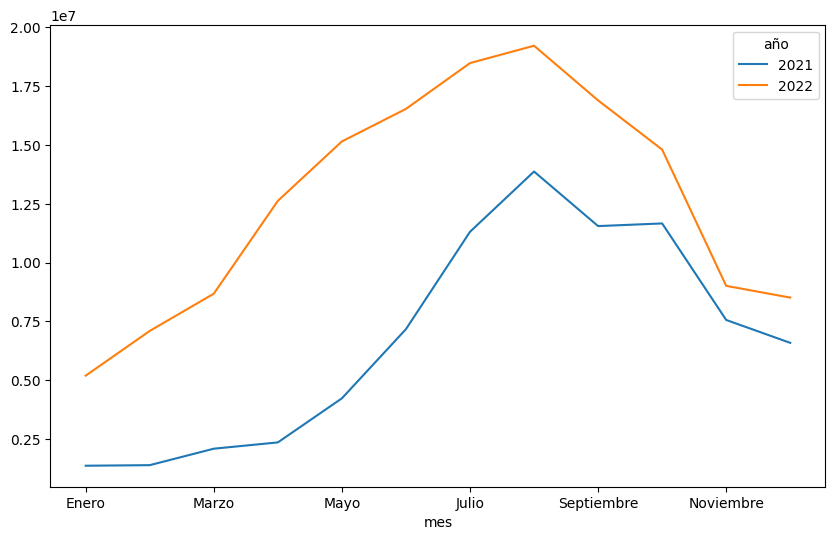

In [28]:
origen.groupby(['mes', 'año'])['viajeros'].sum().unstack().plot(figsize=(10,6))


C:\Users\avril\AppData\Local\Temp\ipykernel_10004\4052109931.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla = origen.groupby(['mes','año'])['viajeros'].sum().unstack()


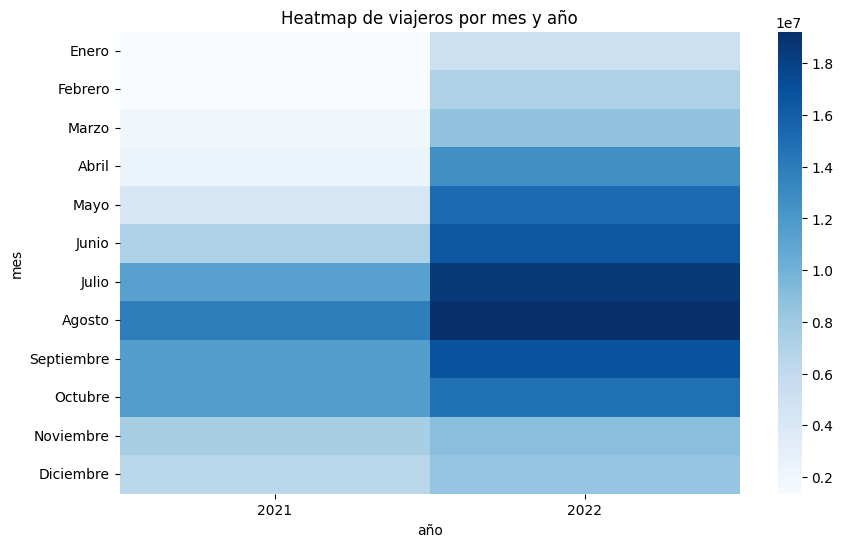

In [29]:
tabla = origen.groupby(['mes','año'])['viajeros'].sum().unstack()

plt.figure(figsize=(10,6))
sns.heatmap(tabla, cmap='Blues', annot=False)
plt.title('Heatmap de viajeros por mes y año')
plt.show()


In [30]:
ranking = origen.groupby(['año','pais'])['viajeros'].sum().groupby(level=0).rank(ascending=False)
ranking

año   pais                       
2021  Alemania                        4.0
      América (sin EEUU)              6.0
      Asia (sin Japón)               29.0
      Austria                        21.0
      Bélgica                        11.0
      Dinamarca                      20.0
      Estados Unidos de América       9.0
      Finlandia                      25.0
      Francia                         3.0
      Grecia                         27.0
      Irlanda                        18.0
      Italia                          8.0
      Japón                          28.0
      Luxemburgo                     26.0
      Noruega                        24.0
      Otros Países Europeos          14.0
      Países Bajos                    7.0
      Polonia                        16.0
      Portugal                       10.0
      Reino Unido                     5.0
      República Checa                22.0
      Residentes en España            1.0
      Residentes en el Extranjero     2.0


In [138]:
excluir = ['Residentes en España', 'Residentes en el Extranjero']
origen_filtrado = origen[~origen['pais'].isin(excluir)]

# Calcular el ranking por año y país
ranking = (
    origen_filtrado
    .groupby(['año','pais'])['viajeros']
    .sum()
    .groupby(level=0)
    .rank(ascending=False)
)
ranking


año   pais                     
2021  Alemania                      2.0
      América (sin EEUU)            4.0
      Asia (sin Japón)             27.0
      Austria                      19.0
      Bélgica                       9.0
      Dinamarca                    18.0
      Estados Unidos de América     7.0
      Finlandia                    23.0
      Francia                       1.0
      Grecia                       25.0
      Irlanda                      16.0
      Italia                        6.0
      Japón                        26.0
      Luxemburgo                   24.0
      Noruega                      22.0
      Otros Países Europeos        12.0
      Países Bajos                  5.0
      Polonia                      14.0
      Portugal                      8.0
      Reino Unido                   3.0
      República Checa              20.0
      Resto de la U.E.             11.0
      Resto del Mundo              10.0
      Rusia                        21.0
      Su

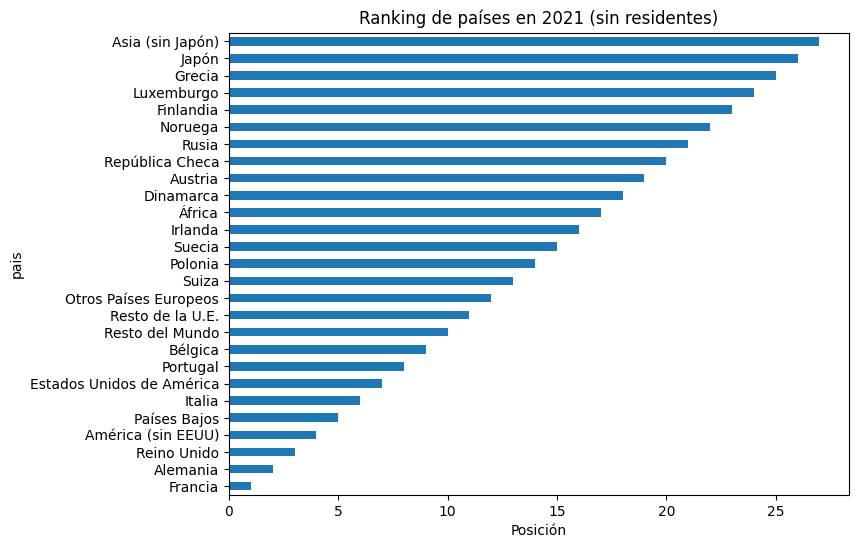

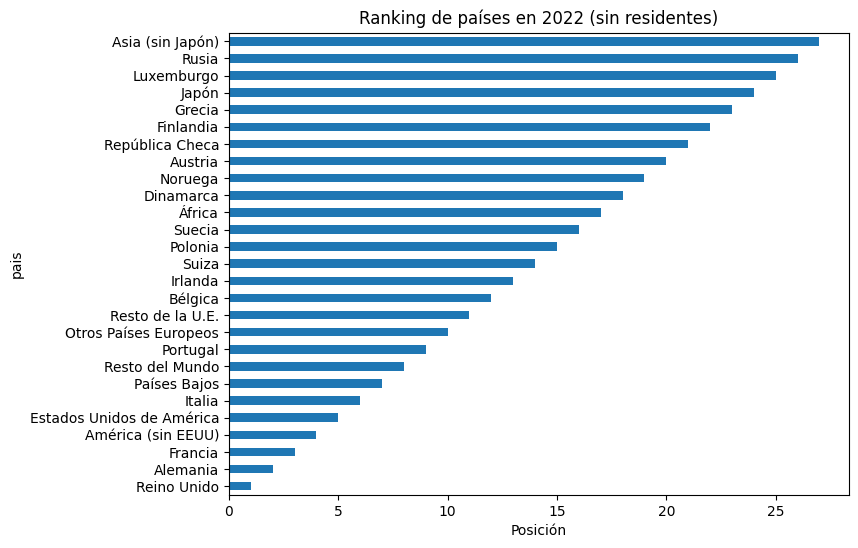

In [139]:
ranking_tabla = ranking.unstack() 
ranking_df = (
    origen_filtrado
    .groupby(['año','pais'])['viajeros']
    .sum()
    .groupby(level=0)
    .rank(ascending=False)
    .unstack()
)

for año in ranking_df.index:
    ranking_df.loc[año].sort_values().plot(
        kind='barh',
        figsize=(8,6),
        title=f'Ranking de países en {año} (sin residentes)'
    )
    plt.xlabel('Posición')
    plt.show()





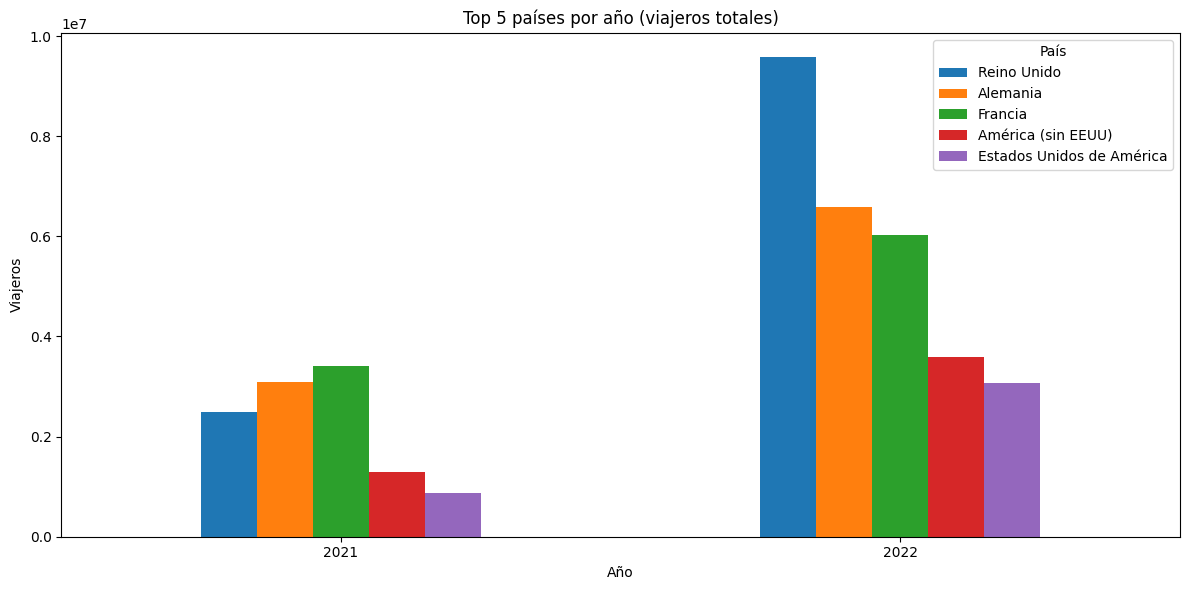

In [33]:
tabla = origen_filtrado.groupby(['año','pais'])['viajeros'].sum().unstack()

#Seleccionar el TOP 5 promedio
top5 = tabla.mean().sort_values(ascending=False).head(5).index
tabla_top5 = tabla[top5]
tabla_top5.plot(kind='bar', figsize=(12,6))
plt.title('Top 5 países por año (viajeros totales)')
plt.ylabel('Viajeros')
plt.xlabel('Año')
plt.xticks(rotation=0)
plt.legend(title='País')
plt.tight_layout()
plt.show()


In [34]:
pais_share = origen.groupby('pais')['viajeros'].sum()
pais_share / pais_share.sum()


pais
Alemania                       0.041486
América (sin EEUU)             0.020947
Asia (sin Japón)               0.000000
Austria                        0.002893
Bélgica                        0.009292
Dinamarca                      0.003930
Estados Unidos de América      0.016932
Finlandia                      0.001793
Francia                        0.040512
Grecia                         0.000804
Irlanda                        0.006381
Italia                         0.016858
Japón                          0.000626
Luxemburgo                     0.000694
Noruega                        0.002943
Otros Países Europeos          0.008476
Países Bajos                   0.015112
Polonia                        0.005990
Portugal                       0.011122
Reino Unido                    0.051753
República Checa                0.002078
Residentes en España           0.401213
Residentes en el Extranjero    0.300177
Resto de la U.E.               0.008993
Resto del Mundo                0.01

In [35]:
origen.groupby(['pais','mes'])['viajeros'].sum().unstack()


C:\Users\avril\AppData\Local\Temp\ipykernel_10004\2601640994.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  origen.groupby(['pais','mes'])['viajeros'].sum().unstack()


mes,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
pais,,,,,,,,,,,,
Alemania,163423.0,215693.0,399289.0,623097.0,908978.0,1157325.0,1212521.0,1228185.0,1453924.0,1311002.0,573347.0,430290.0
América (sin EEUU),176191.0,163855.0,222285.0,310031.0,408233.0,452328.0,557035.0,534992.0,635341.0,622464.0,420771.0,382678.0
Asia (sin Japón),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Austria,13008.0,19753.0,25410.0,52747.0,67744.0,69229.0,92934.0,89043.0,88136.0,84980.0,38839.0,32954.0
Bélgica,62036.0,68686.0,85023.0,130896.0,162194.0,179861.0,359483.0,294003.0,302516.0,253958.0,149448.0,119421.0
Dinamarca,28511.0,37864.0,46164.0,55987.0,60903.0,66339.0,159747.0,89905.0,112879.0,125670.0,76254.0,56379.0
Estados Unidos de América,65274.0,77389.0,167628.0,231400.0,377926.0,484520.0,520014.0,387931.0,547568.0,525438.0,309985.0,254557.0
Finlandia,18741.0,21773.0,29889.0,26510.0,27685.0,28683.0,31334.0,22428.0,33952.0,63056.0,60899.0,53249.0
Francia,205543.0,321994.0,335600.0,577035.0,887858.0,825816.0,1219214.0,1845310.0,1045357.0,1105859.0,571795.0,508445.0


In [36]:
tabla = origen.groupby(['pais','año'])['viajeros'].sum().unstack().fillna(0)
tabla


año,2021,2022
pais,,
Alemania,3085009.0,6592065.0
América (sin EEUU),1293236.0,3592968.0
Asia (sin Japón),0.0,0.0
Austria,193786.0,480991.0
Bélgica,783530.0,1383995.0
Dinamarca,321066.0,595536.0
Estados Unidos de América,871844.0,3077786.0
Finlandia,107588.0,310611.0
Francia,3418911.0,6030915.0


**Destino**

In [37]:
destino

,provincia,origen,periodo,viajeros,año,mes
0,Almería,España,2022M12,33013,2022,Diciembre
1,Almería,España,2022M11,38622,2022,Noviembre
2,Almería,España,2022M10,71229,2022,Octubre
3,Almería,España,2022M09,142904,2022,Septiembre
4,Almería,España,2022M08,206936,2022,Agosto
...,...,...,...,...,...,...
2395,"Rioja, La",El Extranjero,2021M05,1881,2021,Mayo
2396,"Rioja, La",El Extranjero,2021M04,1050,2021,Abril
2397,"Rioja, La",El Extranjero,2021M03,929,2021,Marzo
2398,"Rioja, La",El Extranjero,2021M02,453,2021,Febrero


In [ ]:
destino.shape 

(2400, 6)

In [39]:
destino.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   provincia  2400 non-null   object
 1   origen     2400 non-null   object
 2   periodo    2400 non-null   object
 3   viajeros   2400 non-null   int64 
 4   año        2400 non-null   int64 
 5   mes        2400 non-null   object
dtypes: int64(2), object(4)
memory usage: 112.6+ KB


In [40]:
destino.isna().sum().sort_values(ascending=False)


provincia    0
origen       0
periodo      0
viajeros     0
año          0
mes          0
dtype: int64

In [41]:
destino.columns

Index(['provincia', 'origen', 'periodo', 'viajeros', 'año', 'mes'], dtype='object')

In [42]:
destino['viajeros'] = destino['viajeros'].astype(float)


In [43]:
destino_por_año=destino.groupby('año')['viajeros'].sum()
destino_por_año

año
2021     60651811.0
2022    102747998.0
Name: viajeros, dtype: float64

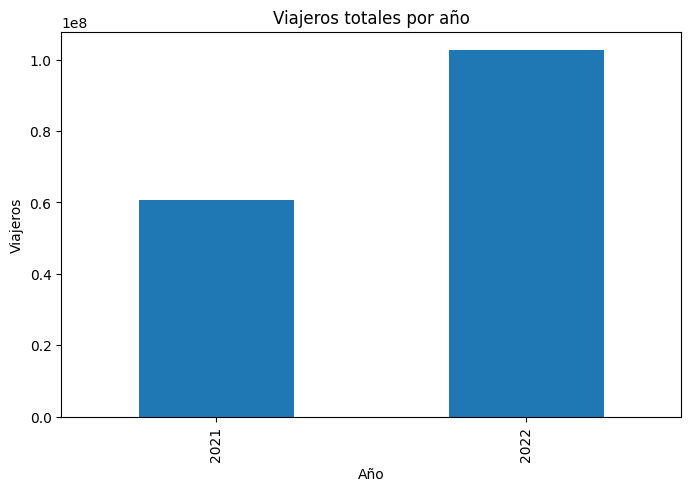

In [44]:
destino.groupby('año')['viajeros'].sum().plot(kind='bar', figsize=(8,5))
plt.title('Viajeros totales por año')
plt.ylabel('Viajeros')
plt.xlabel('Año')
plt.show()

*crecimiento destino*

In [45]:
crecimiento_destino = ((102747998 - 60651811) / 60651811) * 100
print(f"Crecimiento: {crecimiento:.2f}%")


Crecimiento: 87.68%


In [46]:
orden_meses = ['Enero','Febrero','Marzo','Abril','Mayo','Junio',
               'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']

destino['mes'] = destino['mes'].str.strip().str.capitalize()
destino['mes'] = pd.Categorical(destino['mes'], categories=orden_meses, ordered=True)


C:\Users\avril\AppData\Local\Temp\ipykernel_10004\4064646600.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  destino.groupby('mes')['viajeros'].sum().plot(kind='bar', figsize=(10,5))


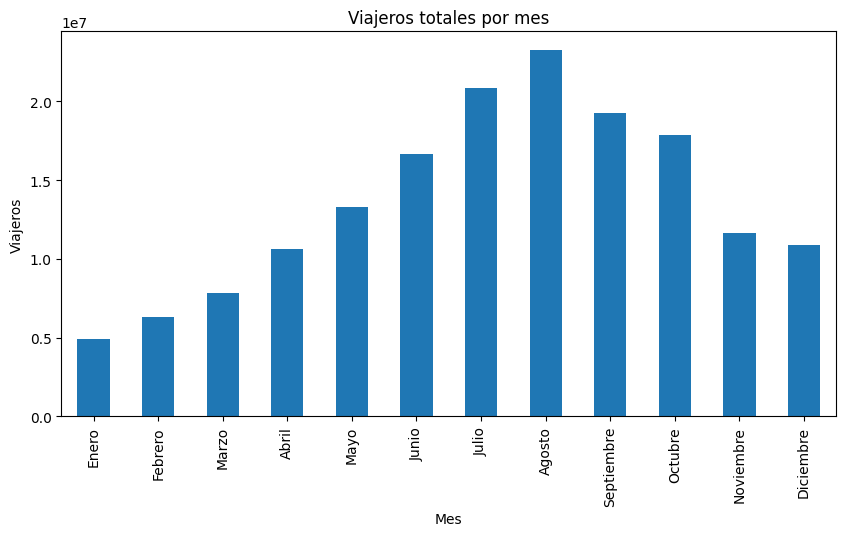

In [47]:
destino.groupby('mes')['viajeros'].sum().plot(kind='bar', figsize=(10,5))
plt.title('Viajeros totales por mes')
plt.ylabel('Viajeros')
plt.xlabel('Mes')
plt.show()


*estacionalidad por origen*

C:\Users\avril\AppData\Local\Temp\ipykernel_10004\385315047.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  destino.groupby(['mes','origen'])['viajeros'].sum().unstack().plot(figsize=(12,6))


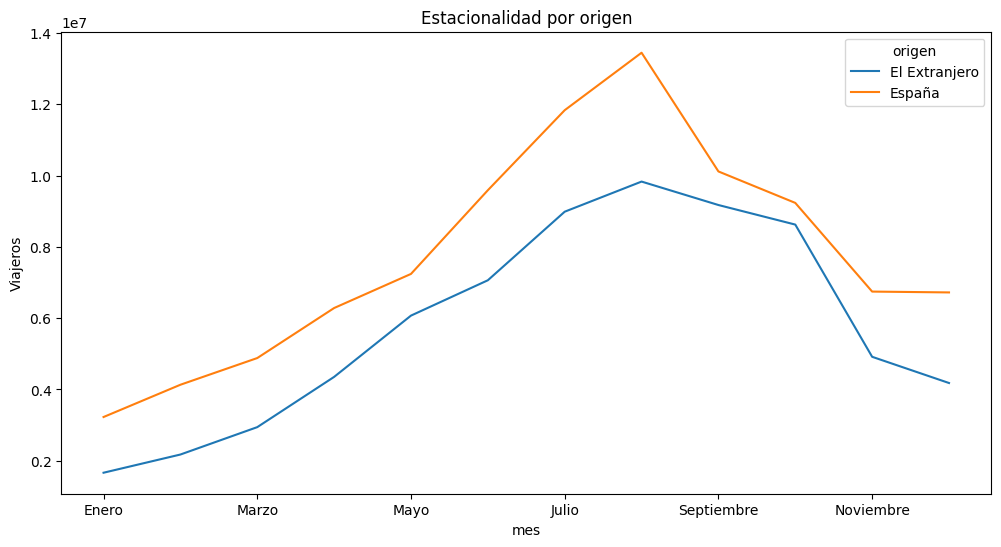

In [48]:
destino.groupby(['mes','origen'])['viajeros'].sum().unstack().plot(figsize=(12,6))
plt.title('Estacionalidad por origen')
plt.ylabel('Viajeros')
plt.show()


*Top 5 por año*

In [49]:
destino['pais_simple'] = destino['origen'].map(lambda x: 'España' if x == 'España' else 'Extranjero')


In [50]:
tabla = destino.groupby(['año','origen'])['viajeros'].sum().unstack()


In [51]:
top5 = tabla.mean().sort_values(ascending=False).head(5).index
tabla_top5 = tabla[top5]


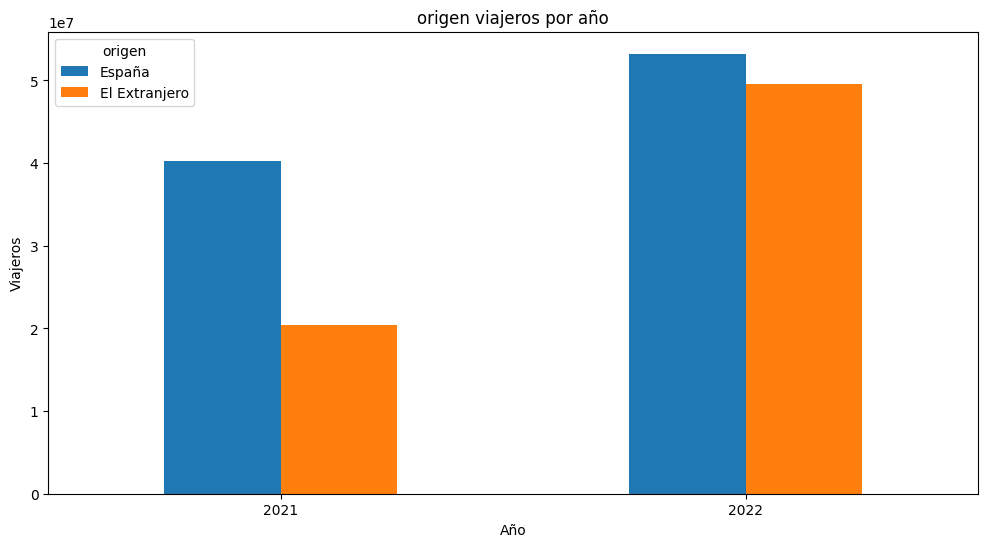

In [140]:
tabla_top5.plot(kind='bar', figsize=(12,6))
plt.title('origen viajeros por año')
plt.ylabel('Viajeros')
plt.xlabel('Año')
plt.xticks(rotation=0)
plt.show()


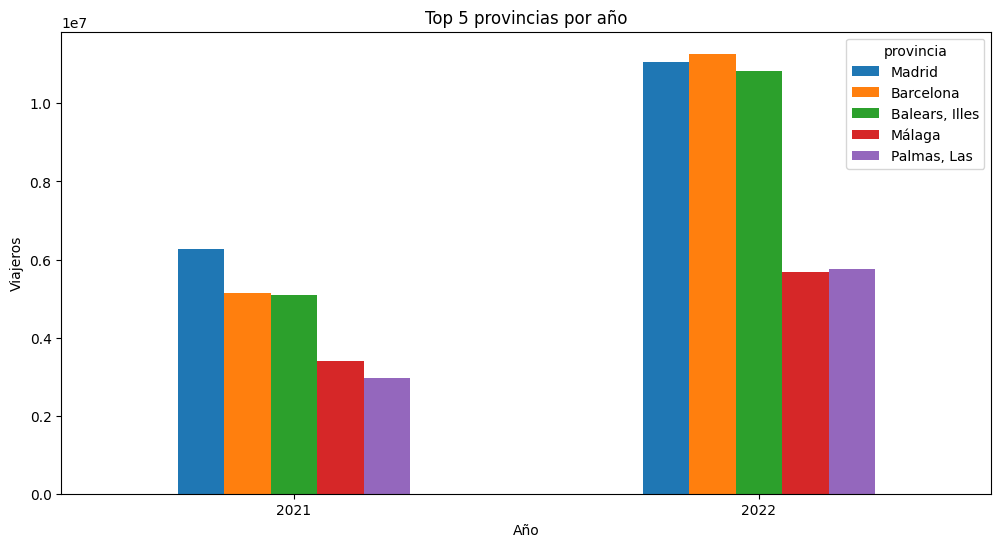

In [53]:
tabla_prov = destino.groupby(['año','provincia'])['viajeros'].sum().unstack()
top5_prov = tabla_prov.mean().sort_values(ascending=False).head(5).index
tabla_prov_top5 = tabla_prov[top5_prov]

tabla_prov_top5.plot(kind='bar', figsize=(12,6))
plt.title('Top 5 provincias por año')
plt.ylabel('Viajeros')
plt.xlabel('Año')
plt.xticks(rotation=0)
plt.show()


In [141]:
tabla_prov_top5

provincia,Madrid,Barcelona,"Balears, Illes",Málaga,"Palmas, Las"
año,,,,,
2021,6265506.0,5151486.0,5082377.0,3393892.0,2969778.0
2022,11060399.0,11271881.0,10827622.0,5673101.0,5748792.0


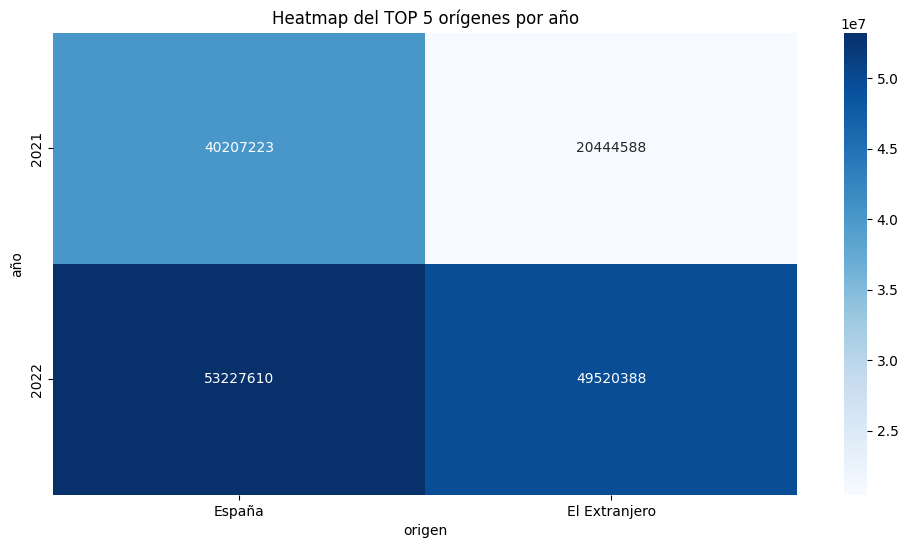

In [54]:
plt.figure(figsize=(12,6))
sns.heatmap(tabla_top5, cmap='Blues', annot=True, fmt='.0f')
plt.title('Heatmap del TOP 5 orígenes por año')
plt.show()


In [55]:
destino.groupby('provincia')['viajeros'].sum().sort_values(ascending=False).head(10)


provincia
Madrid                    17325905.0
Barcelona                 16423367.0
Balears, Illes            15909999.0
Málaga                     9066993.0
Palmas, Las                8718570.0
Alicante/Alacant           6996170.0
Girona                     6518560.0
Santa Cruz de Tenerife     6244911.0
Valencia/València          5539299.0
Sevilla                    5123975.0
Name: viajeros, dtype: float64

<Axes: ylabel='provincia'>

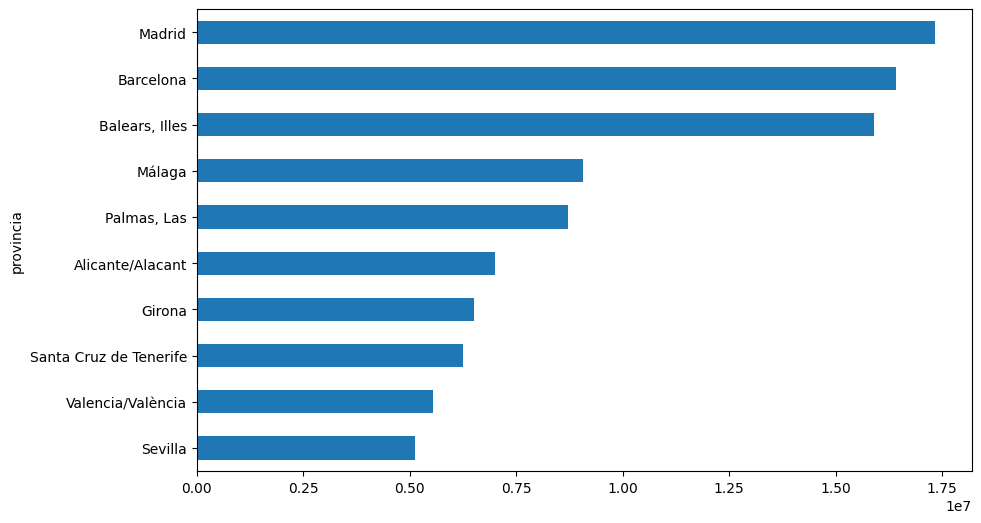

In [56]:
destino.groupby('provincia')['viajeros'].sum().sort_values().tail(10).plot(kind='barh', figsize=(10,6))


<Axes: xlabel='año'>

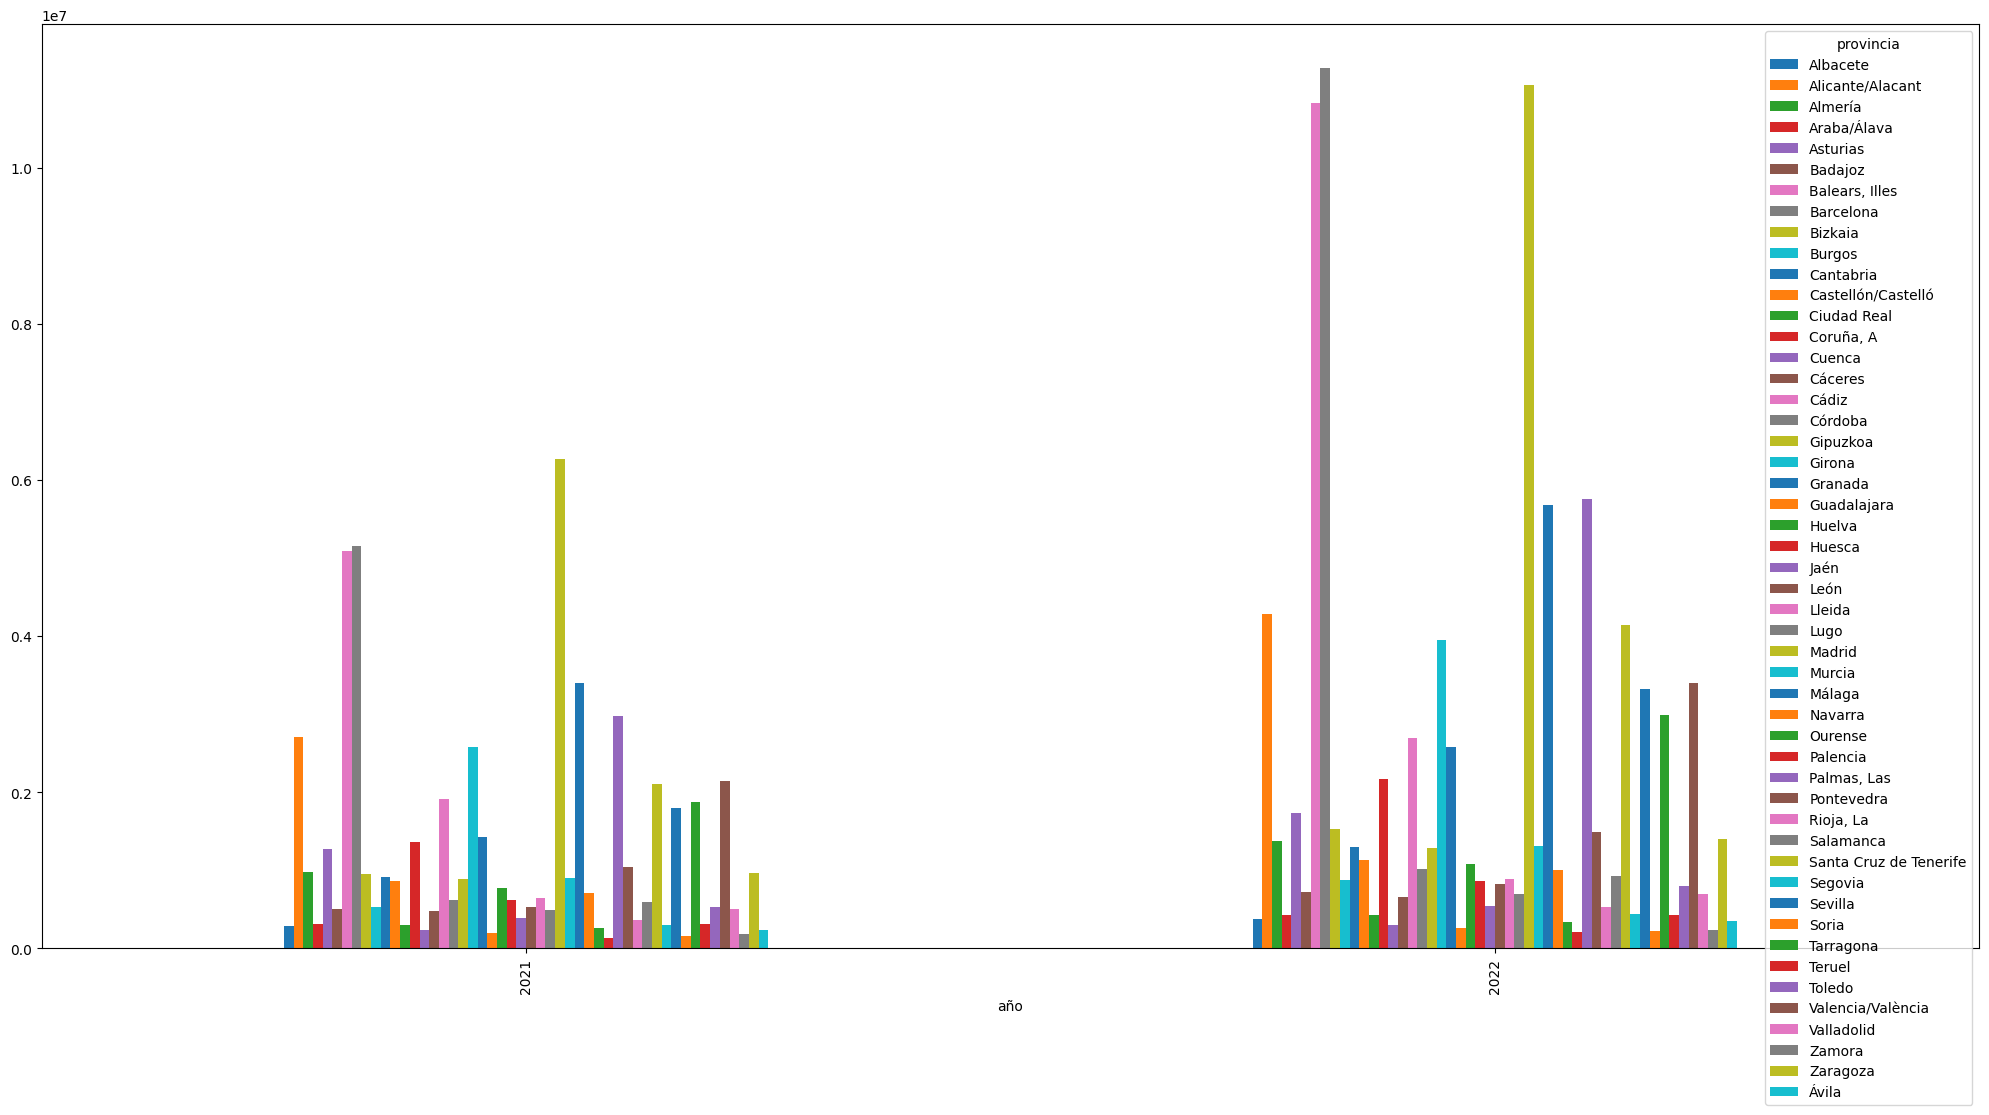

In [145]:
destino.groupby(['año','provincia'])['viajeros'] \
    .sum() \
    .unstack() \
    .plot(kind='bar', figsize=(25,12))



In [58]:
destino.groupby('origen')['viajeros'].sum().sort_values(ascending=False)


origen
España           93434833.0
El Extranjero    69964976.0
Name: viajeros, dtype: float64

<Axes: xlabel='año'>

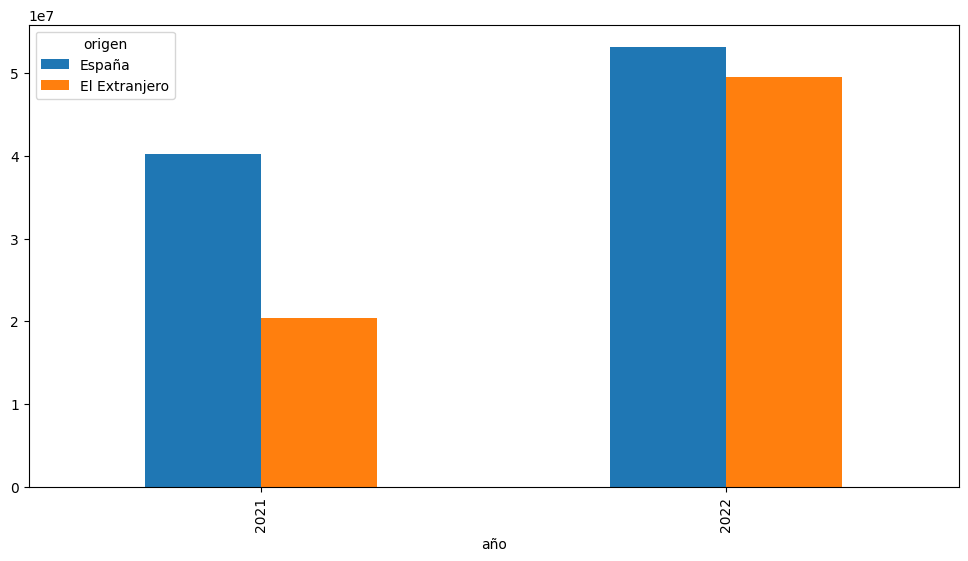

In [59]:
tabla = destino.groupby(['año','origen'])['viajeros'].sum().unstack()
top5 = tabla.mean().sort_values(ascending=False).head(5).index
tabla_top5 = tabla[top5]
tabla_top5.plot(kind='bar', figsize=(12,6))


C:\Users\avril\AppData\Local\Temp\ipykernel_10004\3800784786.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  destino.groupby(['mes','provincia'])['viajeros'].sum().unstack().plot(figsize=(30,20))


<Axes: xlabel='mes'>

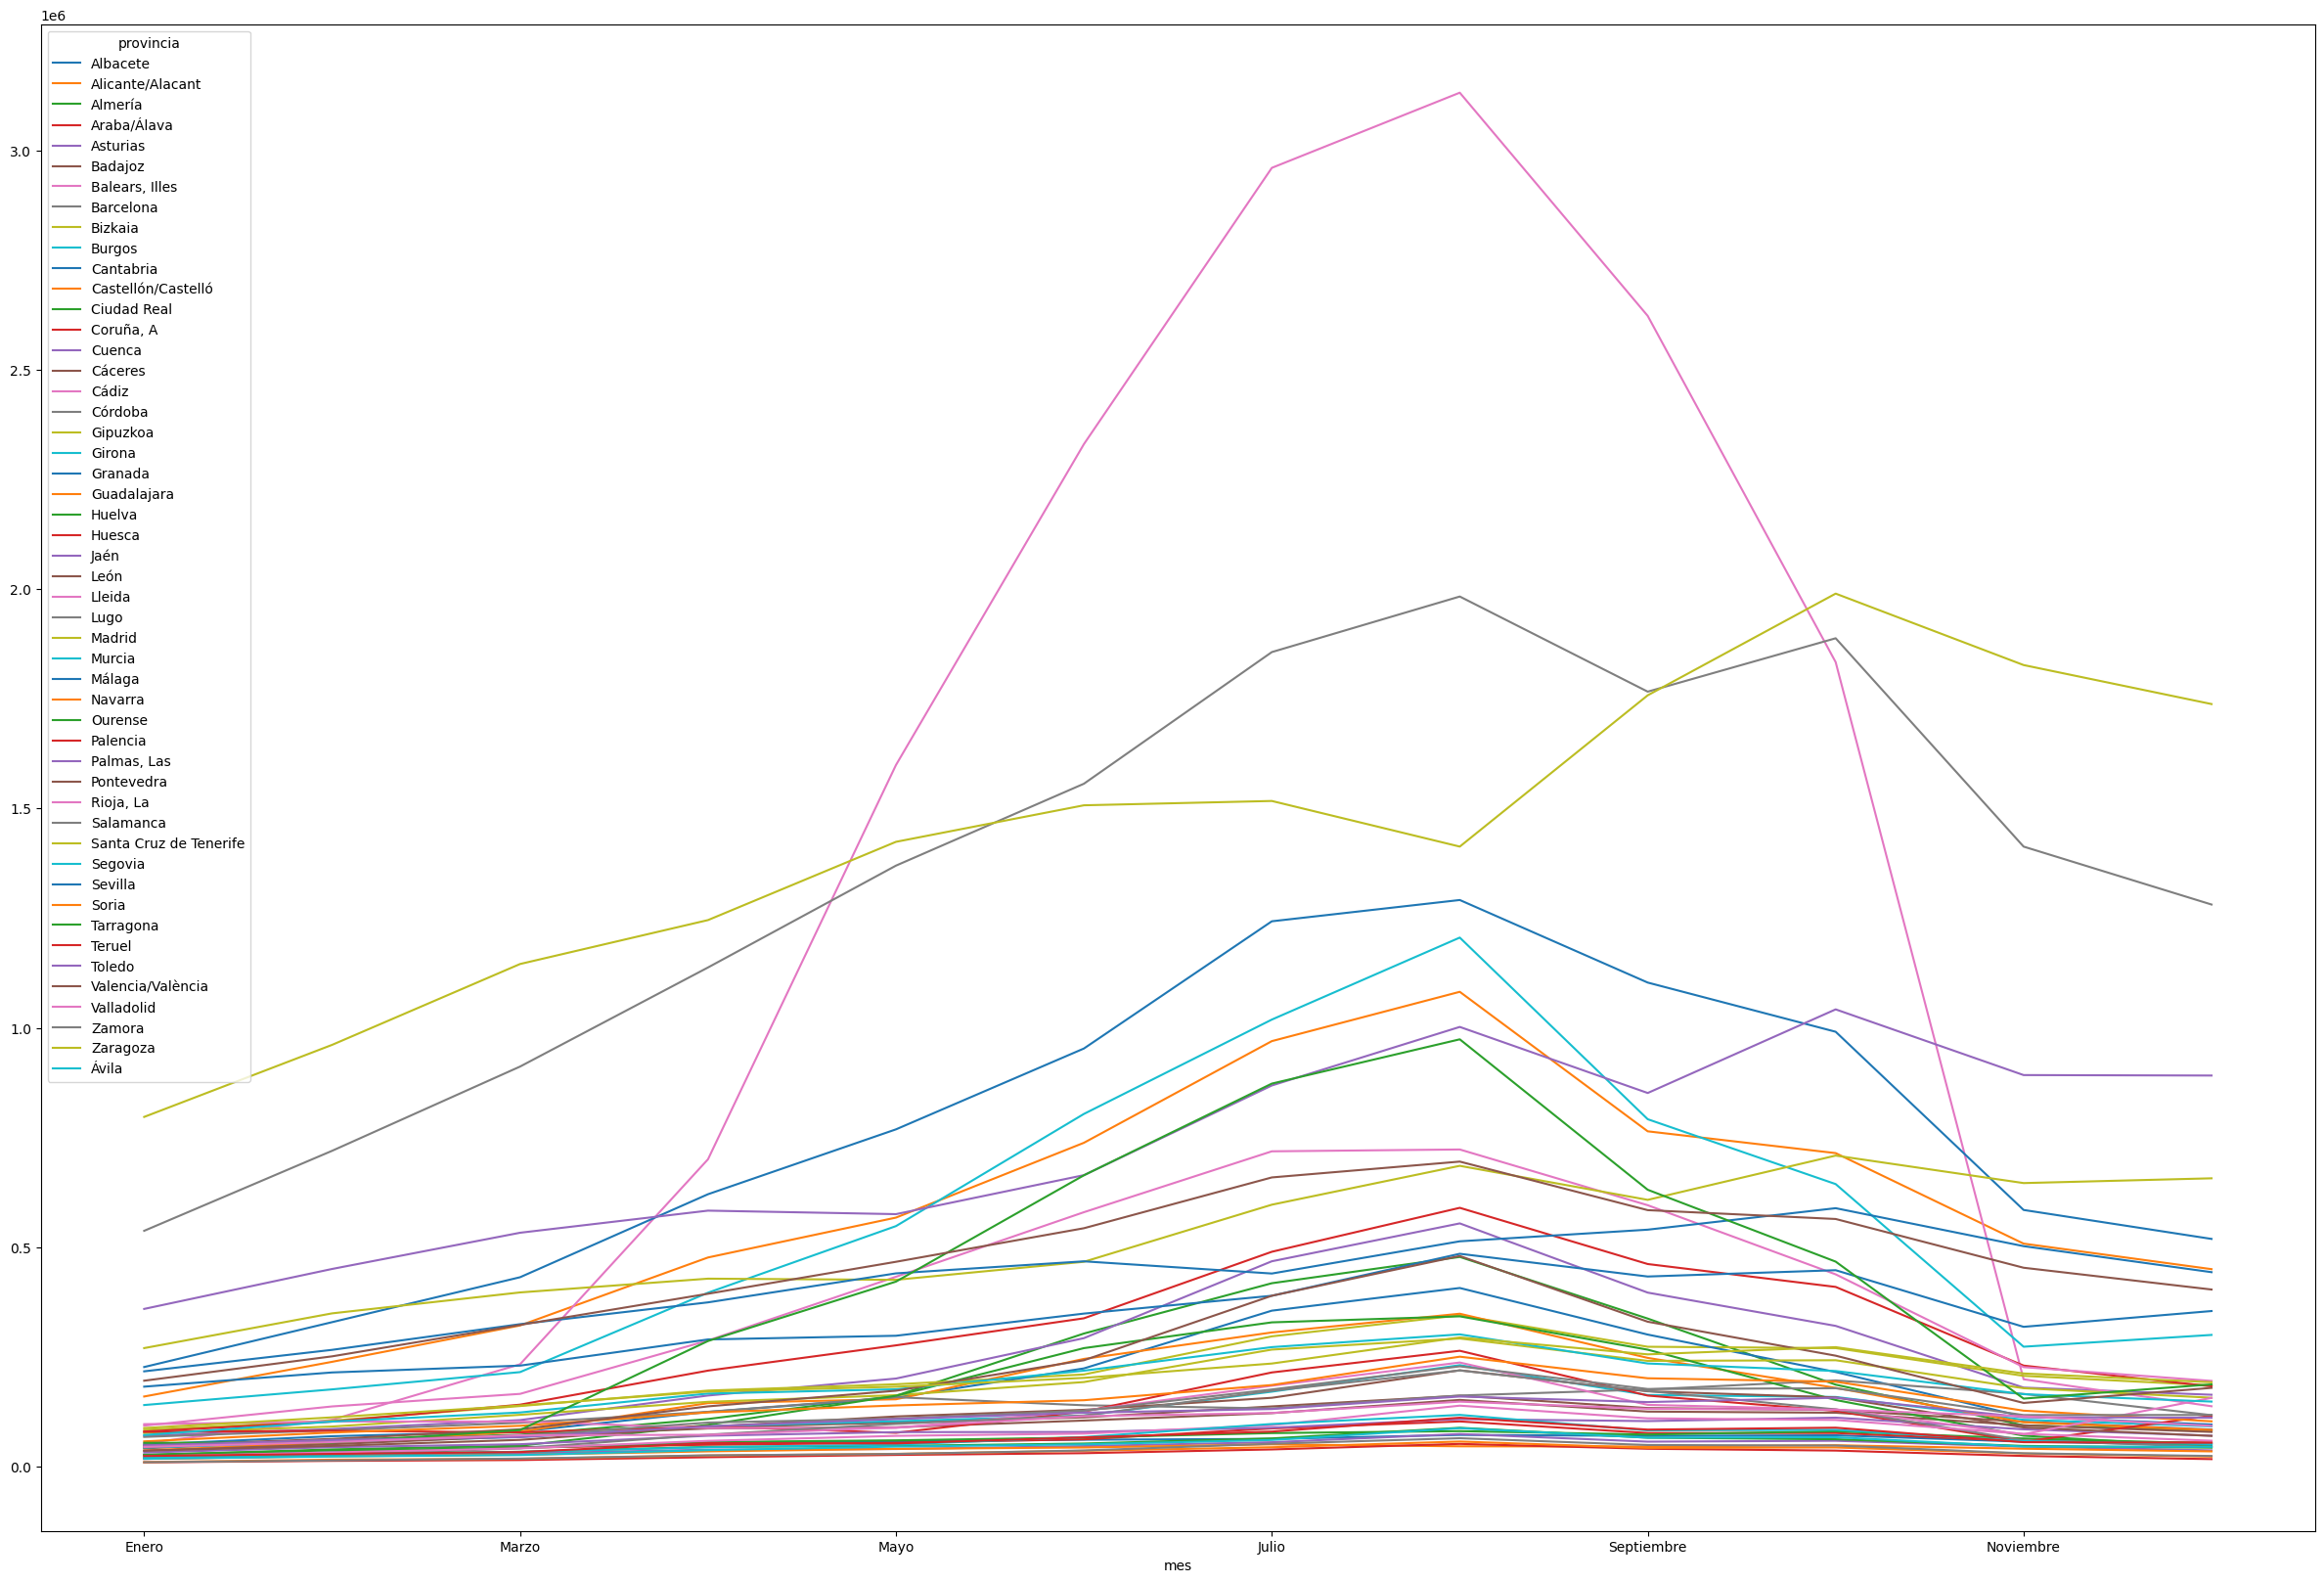

In [60]:
destino.groupby(['mes','provincia'])['viajeros'].sum().unstack().plot(figsize=(30,20))


In [61]:
destino['provincia'].unique()

array(['Almería', 'Cádiz', 'Córdoba', 'Granada', 'Huelva', 'Jaén',
       'Málaga', 'Sevilla', 'Huesca', 'Teruel', 'Zaragoza', 'Asturias',
       'Balears, Illes', 'Palmas, Las', 'Santa Cruz de Tenerife',
       'Cantabria', 'Ávila', 'Burgos', 'León', 'Palencia', 'Salamanca',
       'Segovia', 'Soria', 'Valladolid', 'Zamora', 'Albacete',
       'Ciudad Real', 'Cuenca', 'Guadalajara', 'Toledo', 'Barcelona',
       'Girona', 'Lleida', 'Tarragona', 'Alicante/Alacant',
       'Castellón/Castelló', 'Valencia/València', 'Badajoz', 'Cáceres',
       'Coruña, A', 'Lugo', 'Ourense', 'Pontevedra', 'Madrid', 'Murcia',
       'Navarra', 'Araba/Álava', 'Bizkaia', 'Gipuzkoa', 'Rioja, La'],
      dtype=object)

C:\Users\avril\AppData\Local\Temp\ipykernel_10004\3866881326.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla = df_prov.groupby(['mes','año'])['viajeros'].sum().unstack()


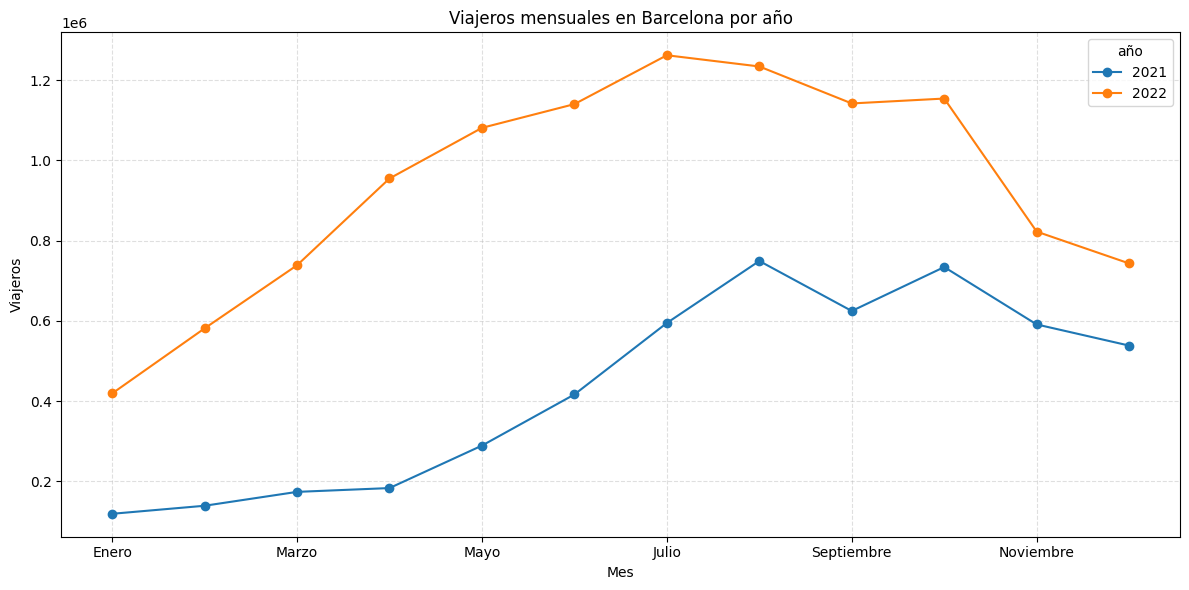

In [62]:
provincia = 'Barcelona'
df_prov = destino[destino['provincia'] == provincia]

# Agrupar por mes y año
tabla = df_prov.groupby(['mes','año'])['viajeros'].sum().unstack()

# Graficar
tabla.plot(figsize=(12,6), marker='o')
plt.title('Viajeros mensuales en Barcelona por año')
plt.ylabel('Viajeros')
plt.xlabel('Mes')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


C:\Users\avril\AppData\Local\Temp\ipykernel_10004\1697672525.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla = df.groupby(['mes','año','provincia'])['viajeros'].sum()


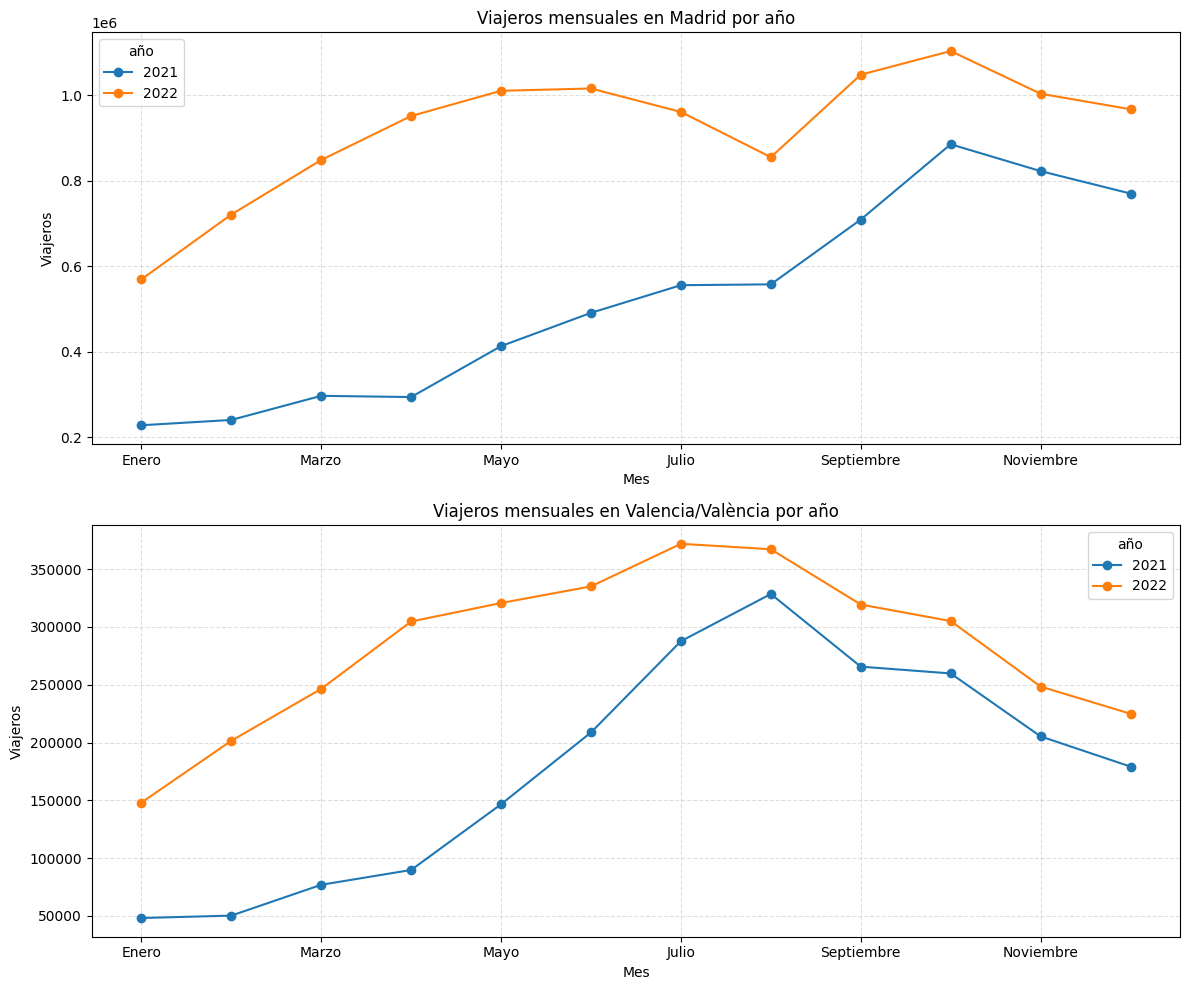

In [146]:
provincias = ['Madrid','Valencia/València' ]  

df = destino[destino['provincia'].isin(provincias)]

tabla = df.groupby(['mes','año','provincia'])['viajeros'].sum()

# Crear un subplot por provincia
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(provincias), 1, figsize=(12, 5*len(provincias)))

for ax, prov in zip(axes, provincias):
    tabla_prov = tabla.loc[:, :, prov].unstack()   # meses × años
    tabla_prov.plot(ax=ax, marker='o')
    ax.set_title(f'Viajeros mensuales en {prov} por año')
    ax.set_xlabel('Mes')
    ax.set_ylabel('Viajeros')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


In [64]:
origen.head(5)

,pais,periodo,viajeros,año,mes,origen,pais_simple
0,Residentes en España,2022M12,3567132.0,2022,Diciembre,España,España
1,Residentes en España,2022M11,3541109.0,2022,Noviembre,España,España
2,Residentes en España,2022M10,4657750.0,2022,Octubre,España,España
3,Residentes en España,2022M09,5178258.0,2022,Septiembre,España,España
4,Residentes en España,2022M08,6526507.0,2022,Agosto,España,España


In [65]:
origen['pais'].unique()

array(['Residentes en España', 'Residentes en el Extranjero', 'Alemania',
       'Austria', 'Bélgica', 'Dinamarca', 'Finlandia', 'Francia',
       'Grecia', 'Irlanda', 'Italia', 'Luxemburgo', 'Países Bajos',
       'Polonia', 'Portugal', 'República Checa', 'Suecia',
       'Resto de la U.E.', 'Noruega', 'Reino Unido', 'Rusia', 'Suiza',
       'Otros Países Europeos', 'África', 'Resto del Mundo',
       'América (sin EEUU)', 'Estados Unidos de América', 'Japón',
       'Asia (sin Japón)'], dtype=object)

In [66]:
destino.head(5)

,provincia,origen,periodo,viajeros,año,mes,pais_simple
0,Almería,España,2022M12,33013.0,2022,Diciembre,España
1,Almería,España,2022M11,38622.0,2022,Noviembre,España
2,Almería,España,2022M10,71229.0,2022,Octubre,España
3,Almería,España,2022M09,142904.0,2022,Septiembre,España
4,Almería,España,2022M08,206936.0,2022,Agosto,España


In [67]:
origen['pais'].unique()

array(['Residentes en España', 'Residentes en el Extranjero', 'Alemania',
       'Austria', 'Bélgica', 'Dinamarca', 'Finlandia', 'Francia',
       'Grecia', 'Irlanda', 'Italia', 'Luxemburgo', 'Países Bajos',
       'Polonia', 'Portugal', 'República Checa', 'Suecia',
       'Resto de la U.E.', 'Noruega', 'Reino Unido', 'Rusia', 'Suiza',
       'Otros Países Europeos', 'África', 'Resto del Mundo',
       'América (sin EEUU)', 'Estados Unidos de América', 'Japón',
       'Asia (sin Japón)'], dtype=object)

In [68]:
merged = destino.merge(
    origen,
    on=['origen','año','mes'],
    how='left',
    suffixes=('_destino', '_origen')
)


In [69]:
merged.head(5)

,provincia,origen,periodo_destino,viajeros_destino,año,mes,pais_simple_destino,pais,periodo_origen,viajeros_origen,pais_simple_origen
0,Almería,España,2022M12,33013.0,2022,Diciembre,España,Residentes en España,2022M12,3567132.0,España
1,Almería,España,2022M11,38622.0,2022,Noviembre,España,Residentes en España,2022M11,3541109.0,España
2,Almería,España,2022M10,71229.0,2022,Octubre,España,Residentes en España,2022M10,4657750.0,España
3,Almería,España,2022M09,142904.0,2022,Septiembre,España,Residentes en España,2022M09,5178258.0,España
4,Almería,España,2022M08,206936.0,2022,Agosto,España,Residentes en España,2022M08,6526507.0,España


In [70]:
destino['provincia'].unique()

array(['Almería', 'Cádiz', 'Córdoba', 'Granada', 'Huelva', 'Jaén',
       'Málaga', 'Sevilla', 'Huesca', 'Teruel', 'Zaragoza', 'Asturias',
       'Balears, Illes', 'Palmas, Las', 'Santa Cruz de Tenerife',
       'Cantabria', 'Ávila', 'Burgos', 'León', 'Palencia', 'Salamanca',
       'Segovia', 'Soria', 'Valladolid', 'Zamora', 'Albacete',
       'Ciudad Real', 'Cuenca', 'Guadalajara', 'Toledo', 'Barcelona',
       'Girona', 'Lleida', 'Tarragona', 'Alicante/Alacant',
       'Castellón/Castelló', 'Valencia/València', 'Badajoz', 'Cáceres',
       'Coruña, A', 'Lugo', 'Ourense', 'Pontevedra', 'Madrid', 'Murcia',
       'Navarra', 'Araba/Álava', 'Bizkaia', 'Gipuzkoa', 'Rioja, La'],
      dtype=object)

In [71]:
merged.groupby(['pais_simple_origen','provincia'])['viajeros_destino'].sum()


pais_simple_origen  provincia        
España              Albacete              603881.0
                    Alicante/Alacant     4390778.0
                    Almería              1943719.0
                    Araba/Álava           534730.0
                    Asturias             2579666.0
                                           ...    
Extranjero          Valencia/València    2019470.0
                    Valladolid            196362.0
                    Zamora                 41097.0
                    Zaragoza              496541.0
                    Ávila                  56909.0
Name: viajeros_destino, Length: 100, dtype: float64

In [72]:
merged.groupby(['pais_simple_origen','provincia'])['viajeros_destino'].sum().sort_values(ascending=False)


pais_simple_origen  provincia     
Extranjero          Balears, Illes    13123914.0
                    Barcelona         10820394.0
España              Madrid            10681255.0
Extranjero          Madrid             6644650.0
                    Palmas, Las        6456195.0
                                         ...    
                    Ourense              57488.0
                    Ávila                56909.0
                    Guadalajara          47899.0
                    Zamora               41097.0
                    Soria                27627.0
Name: viajeros_destino, Length: 100, dtype: float64

<Axes: title={'center': 'Distribución provincial de viajeros de España'}, ylabel='provincia'>

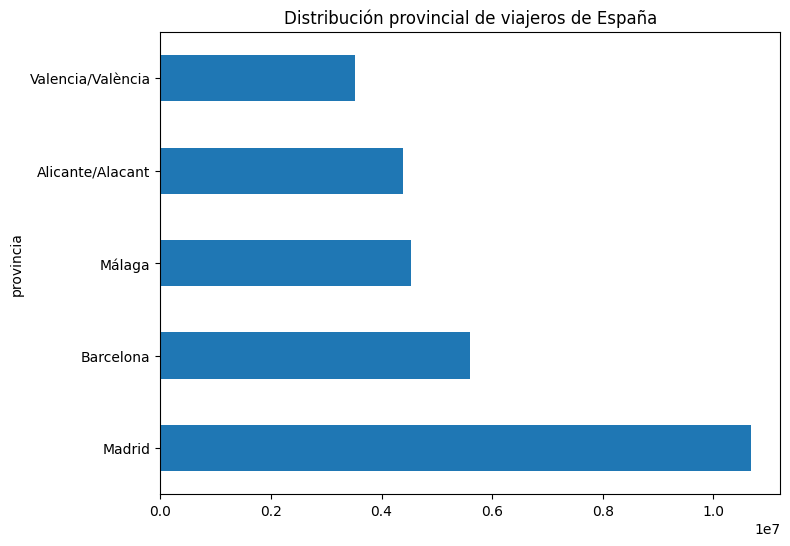

In [73]:
pais = 'España' 
(
    merged[merged['pais_simple_origen'] == pais]
    .groupby('provincia')['viajeros_destino']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .plot(kind='barh', figsize=(8,6), title=f'Distribución provincial de viajeros de {pais}')
)


<Axes: title={'center': 'Distribución provincial de viajeros de Extranjero'}, ylabel='provincia'>

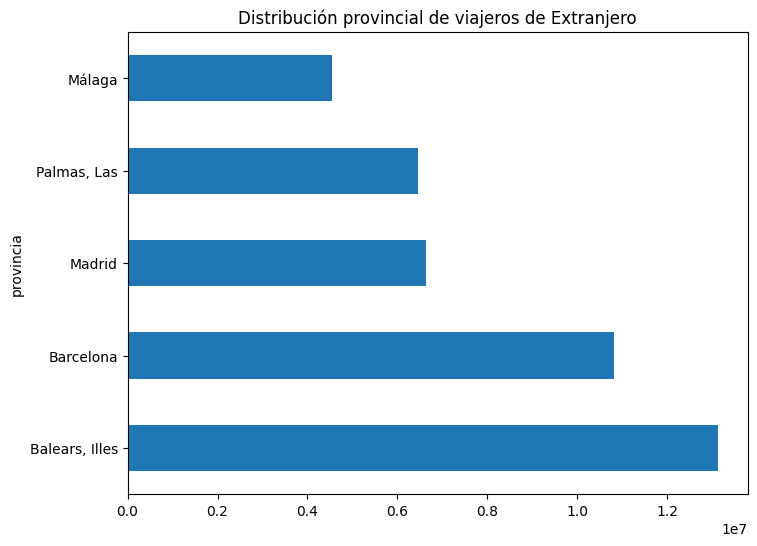

In [74]:
pais = 'Extranjero'  
(
    merged[merged['pais_simple_origen'] == pais]
    .groupby('provincia')['viajeros_destino']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .plot(kind='barh', figsize=(8,6), title=f'Distribución provincial de viajeros de {pais}')
)


<Axes: title={'center': 'Distribución provincial de viajeros de España'}, ylabel='provincia'>

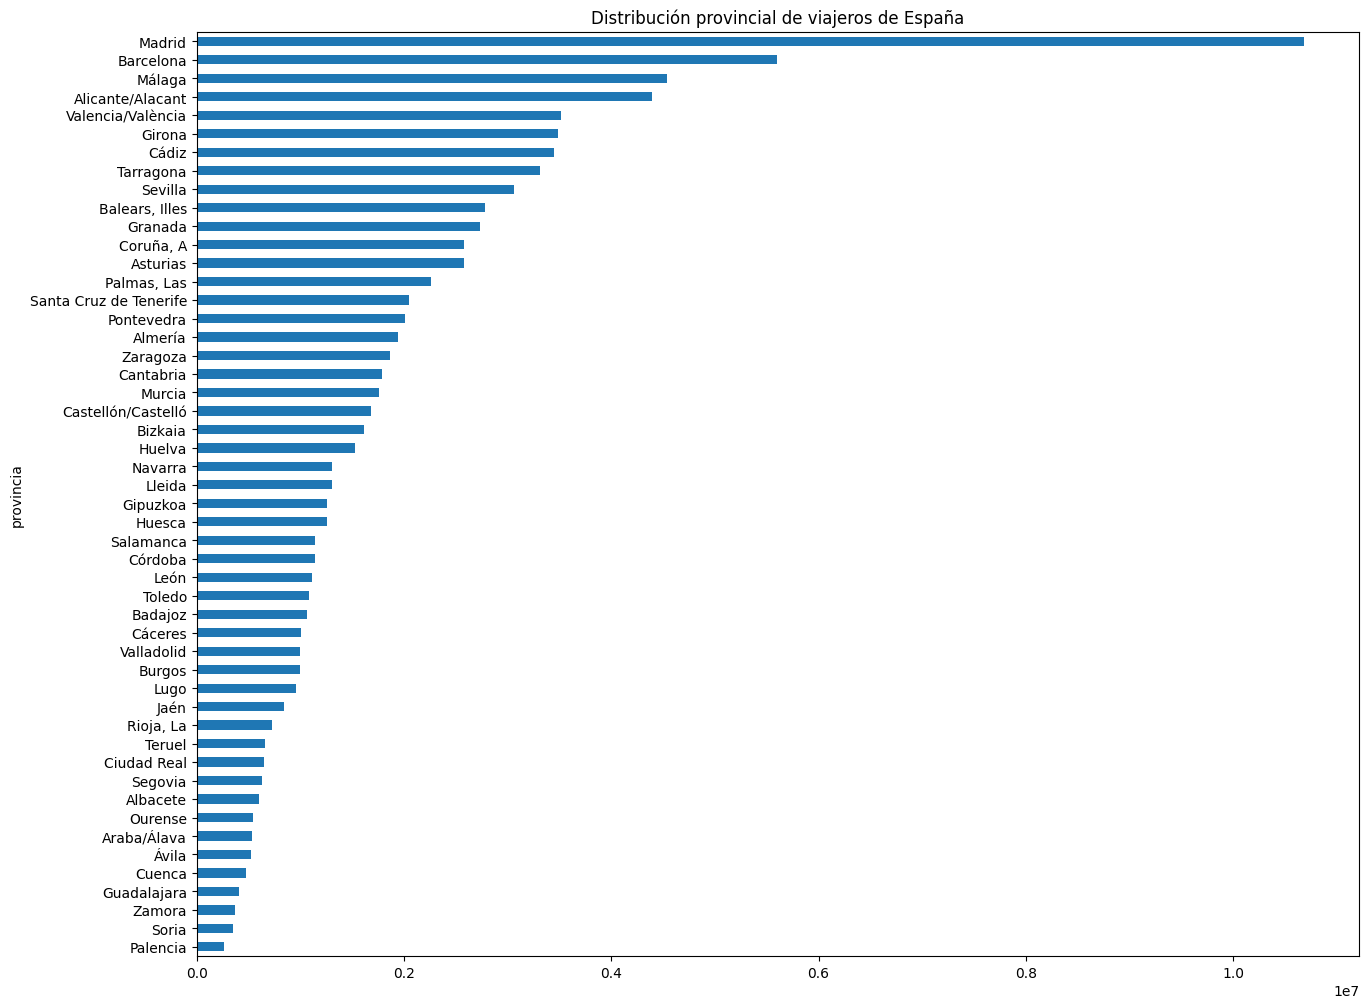

In [75]:
pais = 'España'

(
    merged[merged['pais_simple_origen'] == pais]
    .groupby('provincia')['viajeros_destino']
    .sum()
    .sort_values()
    .plot(kind='barh', figsize=(15,12), title=f'Distribución provincial de viajeros de {pais}')
)


<Axes: title={'center': 'Distribución provincial de viajeros de Extranjero'}, ylabel='provincia'>

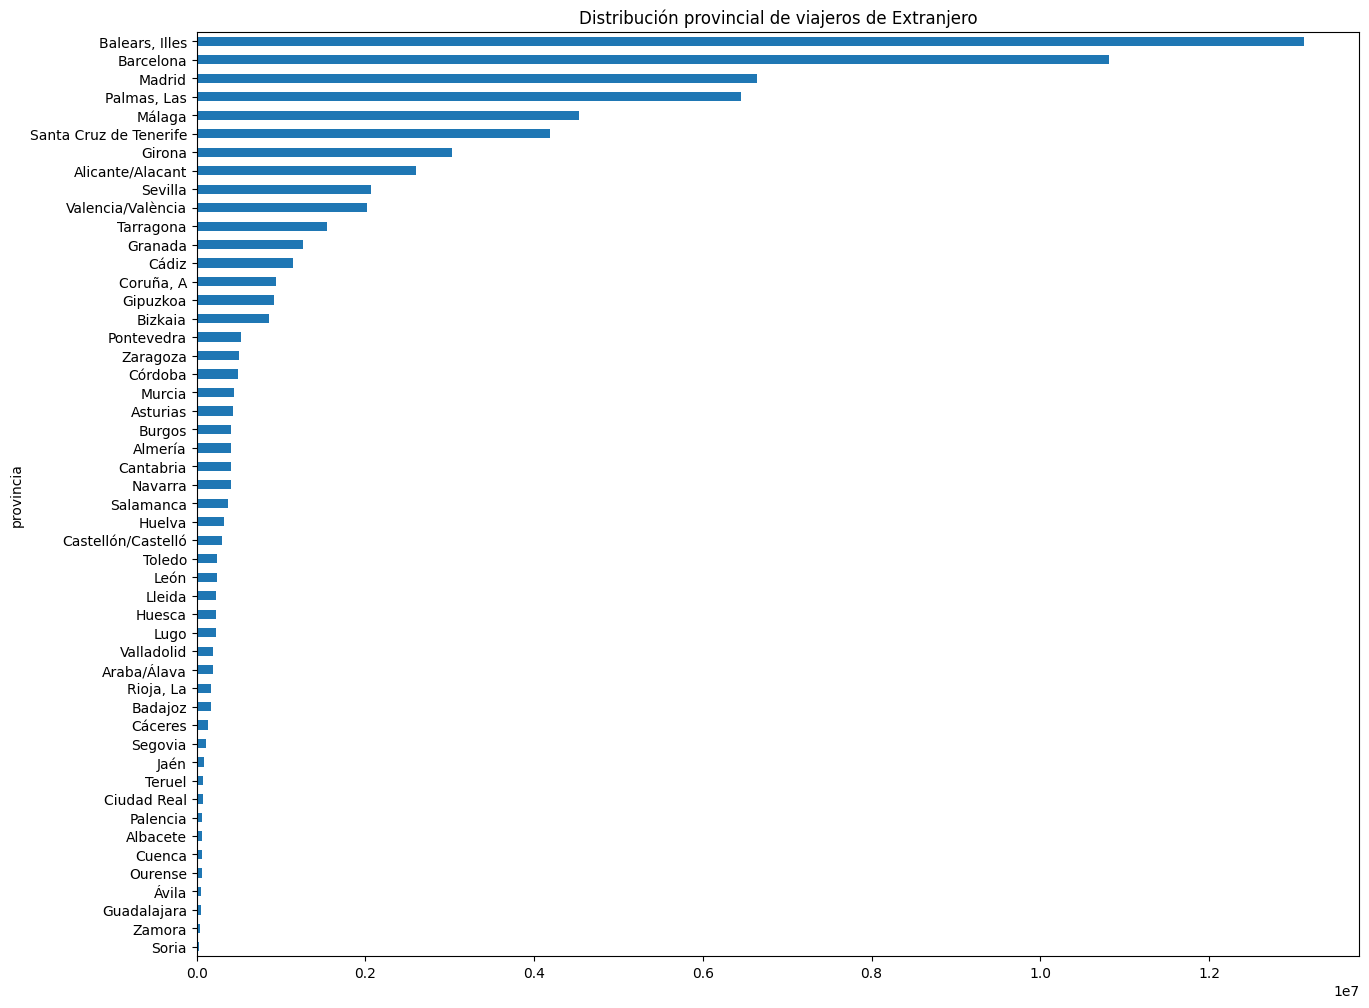

In [76]:
pais = 'Extranjero'

(
    merged[merged['pais_simple_origen'] == pais]
    .groupby('provincia')['viajeros_destino']
    .sum()
    .sort_values()
    .plot(kind='barh', figsize=(15,12), title=f'Distribución provincial de viajeros de {pais}')
)

In [148]:
pais = 'España'

df = merged[merged['pais_simple_origen'] == pais]

df_prov = df.groupby('provincia')['viajeros_destino'].sum()
df_total = df_prov.sum()

(df_prov / df_total * 100).sort_values(ascending=False)


provincia
Madrid                    11.431770
Barcelona                  5.996664
Málaga                     4.852044
Alicante/Alacant           4.699295
Valencia/València          3.767149
Girona                     3.734634
Cádiz                      3.693633
Tarragona                  3.548729
Sevilla                    3.276187
Balears, Illes             2.981848
Granada                    2.929488
Coruña, A                  2.761187
Asturias                   2.760925
Palmas, Las                2.421340
Santa Cruz de Tenerife     2.196821
Pontevedra                 2.146453
Almería                    2.080294
Zaragoza                   1.997194
Cantabria                  1.917127
Murcia                     1.883423
Castellón/Castelló         1.798809
Bizkaia                    1.731383
Huelva                     1.636035
Navarra                    1.399742
Lleida                     1.392710
Gipuzkoa                   1.344148
Huesca                     1.340736
Salamanca         

In [78]:
pais = 'Extranjero'

df = merged[merged['pais_simple_origen'] == pais]

df_prov = df.groupby('provincia')['viajeros_destino'].sum()
df_total = df_prov.sum()

(df_prov / df_total * 100).sort_values(ascending=False)


provincia
Balears, Illes            18.757834
Barcelona                 15.465444
Madrid                     9.497109
Palmas, Las                9.227753
Málaga                     6.479662
Santa Cruz de Tenerife     5.992019
Girona                     4.329468
Alicante/Alacant           3.723852
Sevilla                    2.948440
Valencia/València          2.886401
Tarragona                  2.202895
Granada                    1.801814
Cádiz                      1.640479
Coruña, A                  1.352531
Gipuzkoa                   1.310347
Bizkaia                    1.232857
Pontevedra                 0.751989
Zaragoza                   0.709699
Córdoba                    0.702081
Murcia                     0.636649
Asturias                   0.610307
Burgos                     0.590291
Almería                    0.585682
Cantabria                  0.583846
Navarra                    0.575491
Salamanca                  0.528137
Huelva                     0.460799
Castellón/Castelló

In [79]:
ranking = (
    merged.groupby(['año','pais_simple_origen','provincia'])['viajeros_destino']
    .sum()
    .groupby(['año','pais_simple_origen'])
    .rank(ascending=False)
)
ranking

año   pais_simple_origen  provincia        
2021  España              Albacete             41.0
                          Alicante/Alacant      4.0
                          Almería              17.0
                          Araba/Álava          44.0
                          Asturias             11.0
                                               ... 
2022  Extranjero          Valencia/València    10.0
                          Valladolid           34.0
                          Zamora               49.0
                          Zaragoza             19.0
                          Ávila                44.0
Name: viajeros_destino, Length: 200, dtype: float64

In [80]:
merged

,provincia,origen,periodo_destino,viajeros_destino,año,mes,pais_simple_destino,pais,periodo_origen,viajeros_origen,pais_simple_origen
0,Almería,España,2022M12,33013.0,2022,Diciembre,España,Residentes en España,2022M12,3567132.0,España
1,Almería,España,2022M11,38622.0,2022,Noviembre,España,Residentes en España,2022M11,3541109.0,España
2,Almería,España,2022M10,71229.0,2022,Octubre,España,Residentes en España,2022M10,4657750.0,España
3,Almería,España,2022M09,142904.0,2022,Septiembre,España,Residentes en España,2022M09,5178258.0,España
4,Almería,España,2022M08,206936.0,2022,Agosto,España,Residentes en España,2022M08,6526507.0,España
...,...,...,...,...,...,...,...,...,...,...,...
2395,"Rioja, La",El Extranjero,2021M05,1881.0,2021,Mayo,Extranjero,Residentes en el Extranjero,2021M05,824057.0,Extranjero
2396,"Rioja, La",El Extranjero,2021M04,1050.0,2021,Abril,Extranjero,Residentes en el Extranjero,2021M04,396696.0,Extranjero
2397,"Rioja, La",El Extranjero,2021M03,929.0,2021,Marzo,Extranjero,Residentes en el Extranjero,2021M03,314013.0,Extranjero
2398,"Rioja, La",El Extranjero,2021M02,453.0,2021,Febrero,Extranjero,Residentes en el Extranjero,2021M02,204009.0,Extranjero


In [81]:
merged['pais'].unique()

array(['Residentes en España', 'Residentes en el Extranjero'],
      dtype=object)

In [82]:
merged[merged['pais_simple_origen'] == 'Extranjero'] \
    .groupby('provincia')['viajeros_destino'].sum() \
    .sort_values(ascending=False)


provincia
Balears, Illes            13123914.0
Barcelona                 10820394.0
Madrid                     6644650.0
Palmas, Las                6456195.0
Málaga                     4533494.0
Santa Cruz de Tenerife     4192315.0
Girona                     3029111.0
Alicante/Alacant           2605392.0
Sevilla                    2062875.0
Valencia/València          2019470.0
Tarragona                  1541255.0
Granada                    1260639.0
Cádiz                      1147761.0
Coruña, A                   946298.0
Gipuzkoa                    916784.0
Bizkaia                     862568.0
Pontevedra                  526129.0
Zaragoza                    496541.0
Córdoba                     491211.0
Murcia                      445431.0
Asturias                    427001.0
Burgos                      412997.0
Almería                     409772.0
Cantabria                   408488.0
Navarra                     402642.0
Salamanca                   369511.0
Huelva                      

In [83]:
merged[merged['provincia'] == 'Barcelona'] \
    .groupby('pais_simple_origen')['viajeros_destino'].sum()


pais_simple_origen
España         5602973.0
Extranjero    10820394.0
Name: viajeros_destino, dtype: float64

In [84]:
merged[merged['provincia'] == 'Girona'] \
    .groupby('pais_simple_origen')['viajeros_destino'].sum()

pais_simple_origen
España        3489449.0
Extranjero    3029111.0
Name: viajeros_destino, dtype: float64

In [85]:
merged[merged['provincia'] == 'Madrid'] \
    .groupby('pais_simple_origen')['viajeros_destino'].sum()

pais_simple_origen
España        10681255.0
Extranjero     6644650.0
Name: viajeros_destino, dtype: float64

<Axes: xlabel='provincia', ylabel='pais_simple_origen'>

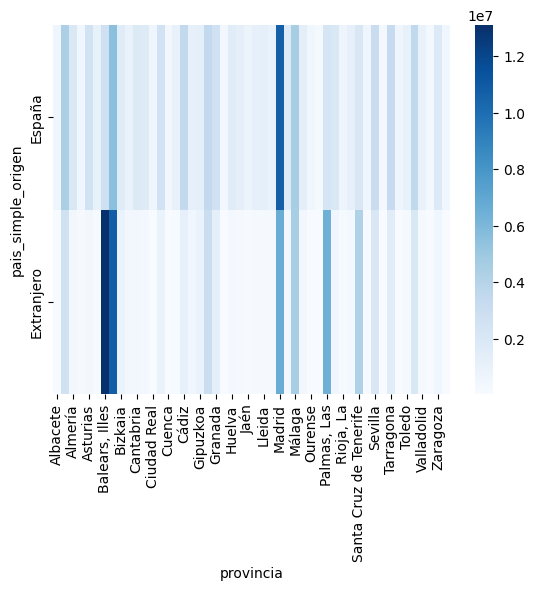

In [86]:
tabla = merged.groupby(['pais_simple_origen','provincia'])['viajeros_destino'].sum().unstack()
sns.heatmap(tabla, cmap='Blues')


In [87]:
("..", "Data", r"C:\Users\avril\itacademy\ProjecteData\Equip_22\Data\INEViajeroOrigenClean11022026.csv")

('..',
 'Data',
 'C:\\Users\\avril\\itacademy\\ProjecteData\\Equip_22\\Data\\INEViajeroOrigenClean11022026.csv')

In [88]:
ruta = os.path.join("..", "Data", r"C:\Users\avril\itacademy\ProjecteData\Equip_22\Data\TouristAccommodationClean02022026.csv")
data = pd.read_csv(ruta)

In [89]:
data.columns

Index(['apartment_id', 'name', 'description', 'host_id', 'neighbourhood_name',
       'neighbourhood_district', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'amenities_list', 'price', 'minimum_nights',
       'maximum_nights', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'first_review_date', 'last_review_date',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'is_instant_bookable', 'reviews_per_month',
       'country', 'city', 'insert_date', 'unique_id', 'city_neighbourhood',
       'ocupacion_30'],
      dtype='object')

In [149]:
tour_city = data.groupby('city')['apartment_id'].count()
turistas_city = merged[merged['pais_simple_origen'] == 'Extranjero'] \
                    .groupby('provincia')['viajeros_destino'].sum()

comparacion = pd.concat([tour_city, turistas_city], axis=1)


Qué ciudades tienen más oferta y reciben más turistas extranjeros?

In [91]:
comparacion

,apartment_id,viajeros_destino
Barcelona,2825.0,10820394.0
Girona,1533.0,3029111.0
Madrid,2202.0,6644650.0
Malaga,520.0,NaN
Mallorca,1644.0,NaN
Menorca,224.0,NaN
Sevilla,524.0,2062875.0
Valencia,528.0,NaN
Albacete,NaN,60209.0
Alicante/Alacant,NaN,2605392.0


In [92]:
data['insert_date'] = pd.to_datetime(data['insert_date'])


C:\Users\avril\AppData\Local\Temp\ipykernel_10004\1581936134.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['insert_date'] = pd.to_datetime(data['insert_date'])


In [93]:
data['month'] = data['insert_date'].dt.month_name()


In [94]:
df = merged.groupby(['provincia','mes'], observed=False)['viajeros_destino'].sum().reset_index()
df2 = data.groupby(['city','month'])['price'].mean().reset_index()
df2

,city,month,price
0,Barcelona,April,837.195122
1,Barcelona,August,930.571429
2,Barcelona,December,758.793860
3,Barcelona,February,821.078767
4,Barcelona,January,810.879121
...,...,...,...
91,Valencia,March,565.151515
92,Valencia,May,655.138889
93,Valencia,November,677.073171
94,Valencia,October,605.365854


In [152]:
df2['price'].head(5)

0    837.195122
1    930.571429
2    758.793860
3    821.078767
4    810.879121
Name: price, dtype: float64

In [151]:
prov = 'Barcelona'
city = 'Barcelona'

df_barcelona = df[df['provincia'] == prov]
df2_barcelona = df2[df2['city'] == city]

comparacion = df_barcelona.merge(df2_barcelona, left_on='mes', right_on='month', how='left')


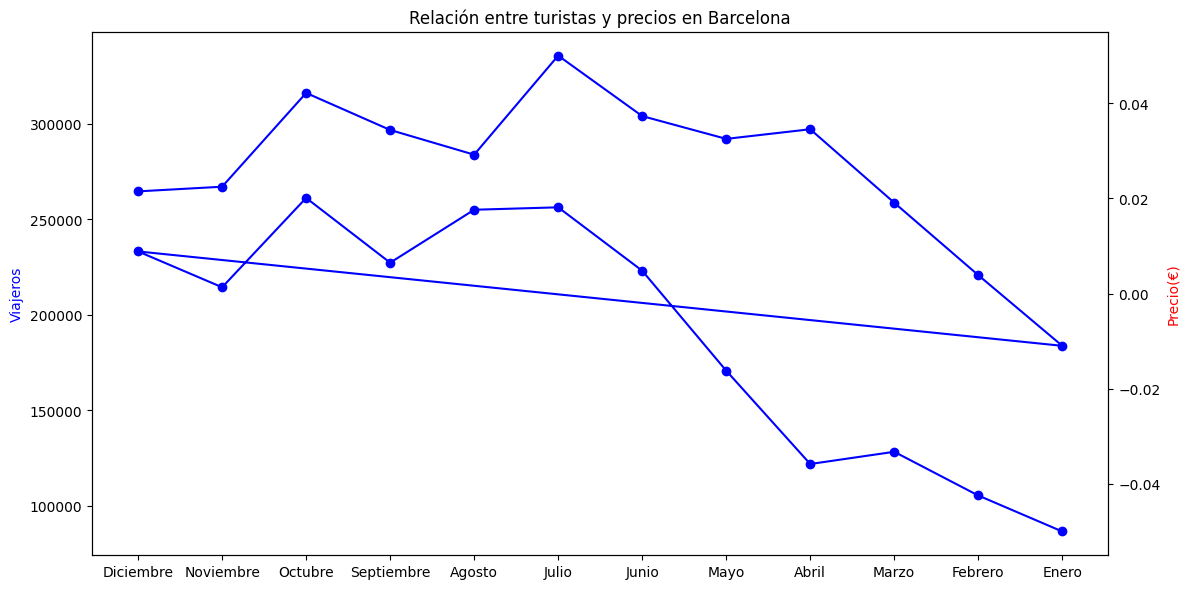

In [153]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(comparacion['mes'], comparacion['viajeros_destino'], color='blue', marker='o')
ax1.set_ylabel('Viajeros', color='blue')

ax2 = ax1.twinx()
ax2.plot(comparacion['mes'], comparacion['price'], color='red', marker='o')
ax2.set_ylabel('Precio(€)', color='red')

plt.title('Relación entre turistas y precios en Barcelona')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [98]:
precio_ciudad = data.groupby('city')['price'].mean().sort_values(ascending=False)
precio_ciudad


city
Mallorca     1640.186740
Menorca      1634.285714
Girona       1201.493803
Sevilla       952.385496
Barcelona     831.506903
Madrid        789.336966
Malaga        744.826923
Valencia      656.257576
Name: price, dtype: float64

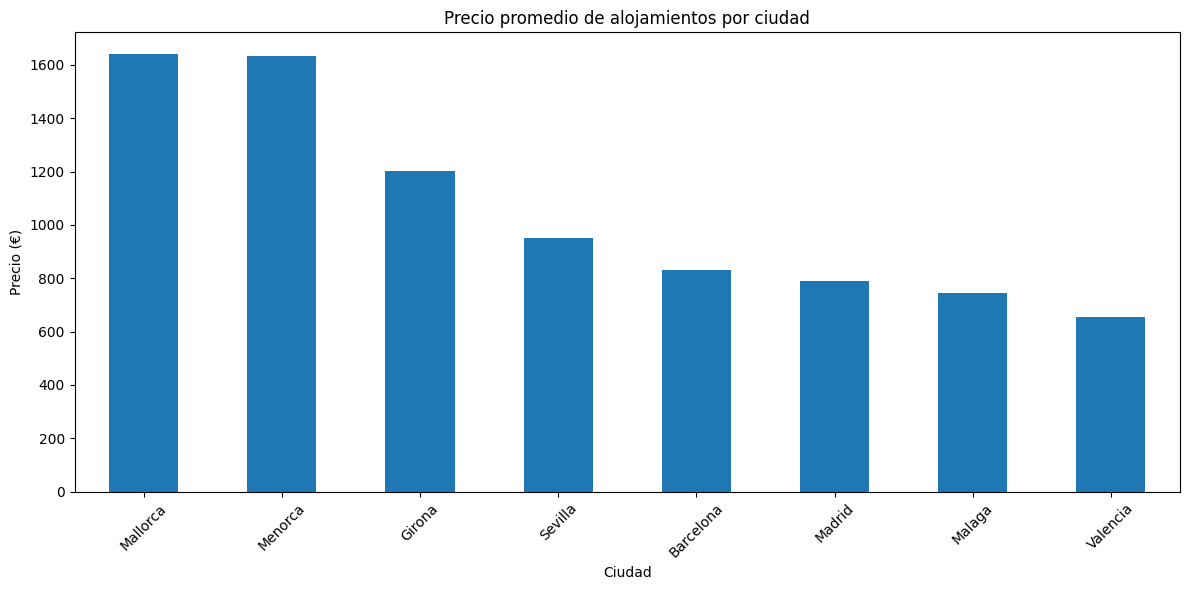

In [99]:
precio_ciudad.plot(kind='bar', figsize=(12,6), title='Precio promedio de alojamientos por ciudad')
plt.ylabel('Precio (€)')
plt.xlabel('Ciudad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


“Calculamos el precio promedio de los alojamientos por ciudad para identificar diferencias en la oferta turística. Esto permite ver qué ciudades tienen alojamientos más caros y cómo se relaciona esto con la demanda turística que vimos en los datasets de origen y destino.”

In [100]:
precio_ciudad = data.groupby('city')['price'].mean().reset_index()
precio_ciudad


,city,price
0,Barcelona,831.506903
1,Girona,1201.493803
2,Madrid,789.336966
3,Malaga,744.826923
4,Mallorca,1640.186740
5,Menorca,1634.285714
6,Sevilla,952.385496
7,Valencia,656.257576


In [101]:
turistas_provincia = merged.groupby('provincia')['viajeros_destino'].sum().reset_index()
turistas_provincia


,provincia,viajeros_destino
0,Albacete,664090.0
1,Alicante/Alacant,6996170.0
2,Almería,2353491.0
3,Araba/Álava,728030.0
4,Asturias,3006667.0
5,Badajoz,1226826.0
6,"Balears, Illes",15909999.0
7,Barcelona,16423367.0
8,Bizkaia,2480283.0
9,Burgos,1406283.0


In [102]:
merged['provincia'].unique()

array(['Almería', 'Cádiz', 'Córdoba', 'Granada', 'Huelva', 'Jaén',
       'Málaga', 'Sevilla', 'Huesca', 'Teruel', 'Zaragoza', 'Asturias',
       'Balears, Illes', 'Palmas, Las', 'Santa Cruz de Tenerife',
       'Cantabria', 'Ávila', 'Burgos', 'León', 'Palencia', 'Salamanca',
       'Segovia', 'Soria', 'Valladolid', 'Zamora', 'Albacete',
       'Ciudad Real', 'Cuenca', 'Guadalajara', 'Toledo', 'Barcelona',
       'Girona', 'Lleida', 'Tarragona', 'Alicante/Alacant',
       'Castellón/Castelló', 'Valencia/València', 'Badajoz', 'Cáceres',
       'Coruña, A', 'Lugo', 'Ourense', 'Pontevedra', 'Madrid', 'Murcia',
       'Navarra', 'Araba/Álava', 'Bizkaia', 'Gipuzkoa', 'Rioja, La'],
      dtype=object)

In [103]:
mapeo = {
    'Barcelona': 'Barcelona',
    'Girona': 'Girona',
    'Madrid': 'Madrid',
    'Malaga': 'Málaga',
    'Mallorca': 'Balears, Illes',
    'Menorca': 'Balears, Illes',
    'Sevilla': 'Sevilla',
    'Valencia': 'Valencia/València'
}


In [104]:
precio_ciudad['provincia'] = precio_ciudad['city'].map(mapeo)


In [105]:
comparacion = precio_ciudad.merge(
    turistas_provincia,
    on='provincia',
    how='inner'
)
comparacion

,city,price,provincia,viajeros_destino
0,Barcelona,831.506903,Barcelona,16423367.0
1,Girona,1201.493803,Girona,6518560.0
2,Madrid,789.336966,Madrid,17325905.0
3,Malaga,744.826923,Málaga,9066993.0
4,Mallorca,1640.186740,"Balears, Illes",15909999.0
5,Menorca,1634.285714,"Balears, Illes",15909999.0
6,Sevilla,952.385496,Sevilla,5123975.0
7,Valencia,656.257576,Valencia/València,5539299.0


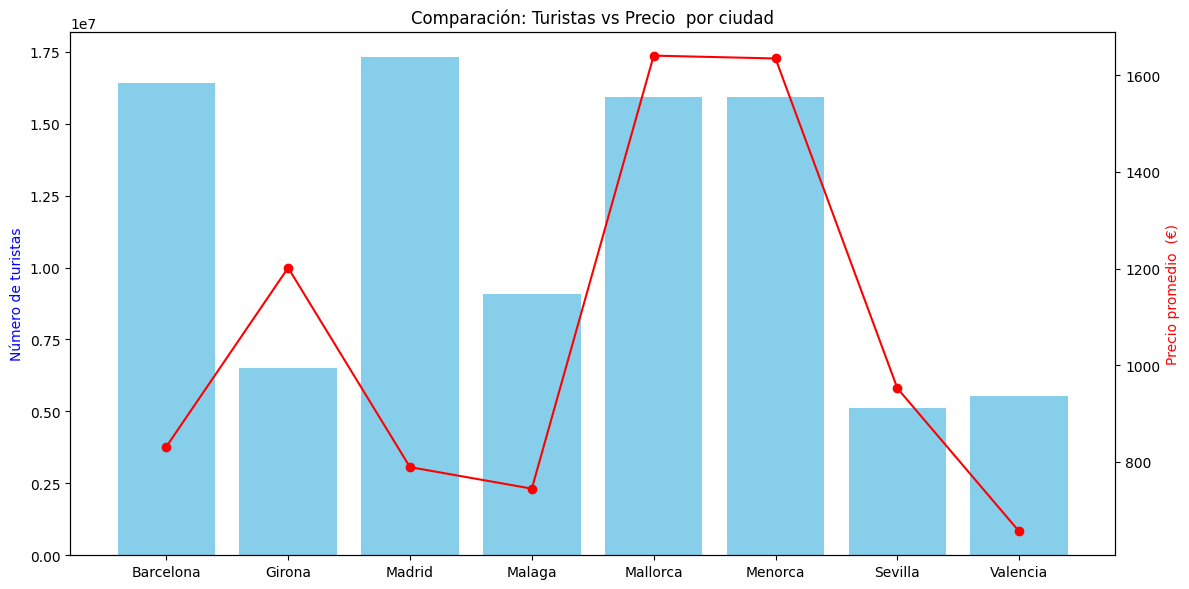

In [106]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,6))

# Turistas
ax1.bar(comparacion['city'], comparacion['viajeros_destino'], color='skyblue')
ax1.set_ylabel('Número de turistas', color='blue')

ax2 = ax1.twinx()
ax2.plot(comparacion['city'], comparacion['price'], color='red', marker='o')
ax2.set_ylabel('Precio promedio  (€)', color='red')

plt.title('Comparación: Turistas vs Precio  por ciudad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


“El gráfico muestra que no siempre existe una relación directa entre el número de turistas y el precio del alojamiento. Las islas (Mallorca y Menorca) combinan alta demanda con precios muy elevados, mientras que ciudades como Málaga y Valencia reciben muchos turistas pero mantienen precios más bajos gracias a una oferta más amplia. Madrid y Barcelona se sitúan en un punto intermedio, con mucha demanda y precios moderados.”

Nuestra empresa debe adaptar su estrategia a las tendencias nacionales combinando precios dinámicos, diferenciación por calidad, optimización de la oferta según el tipo de destino y una fuerte orientación al turismo internacional. Esto nos permitirá competir en ciudades con alta oferta, aprovechar la demanda en destinos premium como las islas y mantener una ocupación estable durante todo el año.”

In [107]:
ventas=data["ventas_anuales"] = data["price"] * data["ocupacion_30"] * 12
ventas


0       110400.0
1        61200.0
2        47520.0
3       100800.0
4       324000.0
          ...   
9995    676800.0
9996     13560.0
9997    414000.0
9998    112560.0
9999      4320.0
Length: 10000, dtype: float64

In [108]:
ventas_por_ciudad = data.groupby("city")["ventas_anuales"].sum().reset_index()
ventas_por_ciudad


,city,ventas_anuales
0,Barcelona,491345352.0
1,Girona,328940640.0
2,Madrid,356712108.0
3,Malaga,75258240.0
4,Mallorca,500996640.0
5,Menorca,73518720.0
6,Sevilla,89239320.0
7,Valencia,67460628.0


In [109]:
ventas_por_room = data.groupby("room_type")["ventas_anuales"].sum().reset_index()
ventas_por_room


,room_type,ventas_anuales
0,Entire home/apt,1.683243e+09
1,Hotel room,1.759356e+07
2,Private room,2.775541e+08
3,Shared room,5.080800e+06


In [110]:
ventas_ciudad_room = data.groupby(["city", "room_type"])["ventas_anuales"].sum().reset_index()
ventas_ciudad_room


,city,room_type,ventas_anuales
0,Barcelona,Entire home/apt,343249560.0
1,Barcelona,Hotel room,5920500.0
2,Barcelona,Private room,139569132.0
3,Barcelona,Shared room,2606160.0
4,Girona,Entire home/apt,320749200.0
5,Girona,Hotel room,931920.0
6,Girona,Private room,7259520.0
7,Girona,Shared room,0.0
8,Madrid,Entire home/apt,277546368.0
9,Madrid,Hotel room,2269500.0


In [115]:
data["last_review_date"] = pd.to_datetime(data["last_review_date"], errors="coerce")
df_2020 = data[data["last_review_date"].dt.year == 2020].copy()
df_2020["ventas_anuales_2020"] = df_2020["price"] * df_2020["ocupacion_30"] * 12
ventas_2020 = df_2020["ventas_anuales_2020"].sum()
ventas_2020



np.float64(90693480.0)

In [116]:
df_2020.groupby("city")["ventas_anuales_2020"].sum().reset_index()


,city,ventas_anuales_2020
0,Barcelona,20935200.0
1,Girona,7902360.0
2,Madrid,33481320.0
3,Malaga,2768400.0
4,Mallorca,12134880.0
5,Menorca,1683000.0
6,Sevilla,4432560.0
7,Valencia,7355760.0


In [117]:
df_2020.groupby("room_type")["ventas_anuales_2020"].sum().reset_index()


,room_type,ventas_anuales_2020
0,Entire home/apt,76372200.0
1,Hotel room,1083480.0
2,Private room,12157800.0
3,Shared room,1080000.0


In [118]:
df_2020.groupby(["city", "room_type"])["ventas_anuales_2020"].sum().reset_index()


,city,room_type,ventas_anuales_2020
0,Barcelona,Entire home/apt,15304320.0
1,Barcelona,Hotel room,532800.0
2,Barcelona,Private room,4018080.0
3,Barcelona,Shared room,1080000.0
4,Girona,Entire home/apt,7614360.0
5,Girona,Private room,288000.0
6,Madrid,Entire home/apt,27438000.0
7,Madrid,Private room,6043320.0
8,Madrid,Shared room,0.0
9,Malaga,Entire home/apt,2435040.0


**número de alojamientos**

In [119]:
num_alojamientos = data["apartment_id"].nunique()
num_alojamientos


9650

**Cuantos anfitriones tenemos**

In [120]:
num_clientes = data["host_id"].nunique()
num_clientes


7269

In [134]:
alojamientos_por_ciudad = data.groupby("city")["apartment_id"].nunique().reset_index()
alojamientos_por_ciudad


,city,apartment_id
0,Barcelona,2719
1,Girona,1485
2,Madrid,2134
3,Malaga,504
4,Mallorca,1583
5,Menorca,218
6,Sevilla,494
7,Valencia,513


In [122]:
alojamientos_por_tipo = data.groupby("room_type")["apartment_id"].nunique().reset_index()
alojamientos_por_tipo


,room_type,apartment_id
0,Entire home/apt,6678
1,Hotel room,82
2,Private room,2823
3,Shared room,72


In [125]:
tabla_alojamiento_ciudad = data.pivot_table(
    index="city",
    columns="room_type",
    values="apartment_id",
    aggfunc="nunique",
    fill_value=0
)

tabla_alojamiento_ciudad


room_type,Entire home/apt,Hotel room,Private room,Shared room
city,,,,
Barcelona,1238,22,1431,30
Girona,1390,11,83,1
Madrid,1294,14,796,30
Malaga,405,4,93,3
Mallorca,1415,17,149,4
Menorca,198,0,20,0
Sevilla,385,11,97,1
Valencia,353,3,154,3


In [155]:
#  Conteo por ciudad y tipo de habitación
conteo = (
    data.groupby(["city", "room_type"])["apartment_id"]
        .nunique()
        .reset_index()
)

# alojamientos por ciudad
totales_ciudad = (
    data.groupby("city")["apartment_id"]
        .nunique()
        .reset_index()
        .rename(columns={"apartment_id": "total_ciudad"})
)

df_pct = conteo.merge(totales_ciudad, on="city")

#  porcentaje
df_pct["porcentaje"] = (df_pct["apartment_id"] / df_pct["total_ciudad"]) * 100

df_pct


,city,room_type,apartment_id,total_ciudad,porcentaje
0,Barcelona,Entire home/apt,1238,2719,45.531445
1,Barcelona,Hotel room,22,2719,0.809121
2,Barcelona,Private room,1431,2719,52.629643
3,Barcelona,Shared room,30,2719,1.103347
4,Girona,Entire home/apt,1390,1485,93.602694
5,Girona,Hotel room,11,1485,0.740741
6,Girona,Private room,83,1485,5.589226
7,Girona,Shared room,1,1485,0.067340
8,Madrid,Entire home/apt,1294,2134,60.637301
9,Madrid,Hotel room,14,2134,0.656045


In [130]:
tabla_pct = (
    df_pct.pivot_table(
        index="city",
        columns="room_type",
        values="porcentaje",
        fill_value=0
    )
)

tabla_pct = tabla_pct.applymap(lambda x: f"{x:.2f}%")
tabla_pct

C:\Users\avril\AppData\Local\Temp\ipykernel_10004\229542781.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  tabla_pct = tabla_pct.applymap(lambda x: f"{x:.2f}%")


room_type,Entire home/apt,Hotel room,Private room,Shared room
city,,,,
Barcelona,45.53%,0.81%,52.63%,1.10%
Girona,93.60%,0.74%,5.59%,0.07%
Madrid,60.64%,0.66%,37.30%,1.41%
Malaga,80.36%,0.79%,18.45%,0.60%
Mallorca,89.39%,1.07%,9.41%,0.25%
Menorca,90.83%,0.00%,9.17%,0.00%
Sevilla,77.94%,2.23%,19.64%,0.20%
Valencia,68.81%,0.58%,30.02%,0.58%
